In [1]:
# Importing modules
from astropy.io import fits
import matplotlib.pylab as plt
import numpy as np
from astropy.cosmology import Planck13
cosmo=Planck13
from astropy . coordinates import Distance
from astropy import units as u
from astropy.table import Table
import pandas as pd
from scipy.optimize import curve_fit
from mpl_toolkits.axes_grid1 import make_axes_locatable
from tqdm.notebook import tqdm
import random
import pyarrow.parquet as pq
import flexcode
from flexcode.regression_models import XGBoost
from flexcode import post_processing
from sklearn import preprocessing


In [2]:
# Pandas display options (personal preference)
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 10)

In [3]:
plt.rcParams.update({
    "font.size": 8,  # Base font size
    "figure.figsize": (3.3, 2.5),
    "axes.labelsize": 8,
    "xtick.labelsize": 7,
    "ytick.labelsize": 7,
    "legend.fontsize": 7,
    "text.usetex": False,
    "font.family": "serif",
    "figure.dpi": 300,  # For raster export
    "savefig.dpi": 600  # Higher DPI for saved files
})

### FS2 properties

In [5]:
# List of columns you want to read
columns_to_read = ['id_galaxy_sky', 'id_group_sky', 'ra', 'dec', 'zobs', 'zcos', 'mvir_hosthalo', 'mvir_subhalo','total_ap_dust_Z_VISTA', 'total_ab_dust_Z_VISTA', 'total_ap_dust_Y_VISTA', 'total_ap_dust_J_VISTA', 'total_ap_dust_H_VISTA', 'total_ap_dust_K_VISTA','total_ap_dust_u_VST','total_ab_dust_u_VST',  'total_ap_dust_g_VST', 'total_ap_dust_r_VST', 'total_ab_dust_r_VST', 'total_ap_dust_i_VST']

# Read only those columns
table = pq.read_table('/research/astrodata/4most/WAVES/mock_catalogues/SHARK/official-0-2-0/waves_wide_gals.parquet', columns=columns_to_read)

# Optional: convert to pandas if needed
df = table.to_pandas()

In [6]:
# Importing Euclid FS2 to DataFrame, and renaming some columns
#hdul = fits.open('../Photo_group_project/11401.fits')
#data = hdul[1].data
#cols = hdul[1].columns
#t=Table(data)
#df = t.to_pandas()
df = df.rename(columns={"ra": "RA"})
df = df.rename(columns={"dec": "Dec"})
df = df.rename(columns={"zobs": "Z"})
#df = df.rename(columns={"total_ap_dust_Z_VISTA": "Rpetro"})
df = df.rename(columns={'id_group_sky': "HaloID"})
del table

In [7]:
# Magnitude limiting to r<21
df=df[(df['total_ap_dust_Z_VISTA']<21)]

In [8]:
#only waves-N 
df=df[(df['Dec']>-10)]

In [9]:
regions = [
    {"ra_min": 193.0, "ra_max": 205.0, "dec_min": -2.0, "dec_max": 3.0},   # G09 look alike
    {"ra_min": 174.0, "ra_max": 186.0, "dec_min": -3.0, "dec_max": 2.0},   # G12
    {"ra_min": 211.5, "ra_max": 223.5, "dec_min": -2.0, "dec_max": 3.0},   # G15
    {"ra_min": 165, "ra_max": 170, "dec_min": -2.0, "dec_max": 3.0},   #25 sq deg pencil beam
]

# Apply the filters
mask = (
    ((df["RA"] >= regions[0]["ra_min"]) & (df["RA"] <= regions[0]["ra_max"]) &
     (df["Dec"] >= regions[0]["dec_min"]) & (df["Dec"] <= regions[0]["dec_max"]))
    |
    ((df["RA"] >= regions[1]["ra_min"]) & (df["RA"] <= regions[1]["ra_max"]) &
     (df["Dec"] >= regions[1]["dec_min"]) & (df["Dec"] <= regions[1]["dec_max"]))
    |
    ((df["RA"] >= regions[2]["ra_min"]) & (df["RA"] <= regions[2]["ra_max"]) &
     (df["Dec"] >= regions[2]["dec_min"]) & (df["Dec"] <= regions[2]["dec_max"]))
        |
    ((df["RA"] >= regions[3]["ra_min"]) & (df["RA"] <= regions[3]["ra_max"]) &
     (df["Dec"] >= regions[3]["dec_min"]) & (df["Dec"] <= regions[3]["dec_max"]))
)

# Filter the dataframe
df = df[mask]

(array([145300.,  80926., 181414., 103390.,  37283., 174279., 142451.,
          9624., 183352., 182752.]),
 array([165.00003052, 170.85002136, 176.70002747, 182.55001831,
        188.40002441, 194.25001526, 200.1000061 , 205.95001221,
        211.80000305, 217.65000916, 223.5       ]),
 <BarContainer object of 10 artists>)

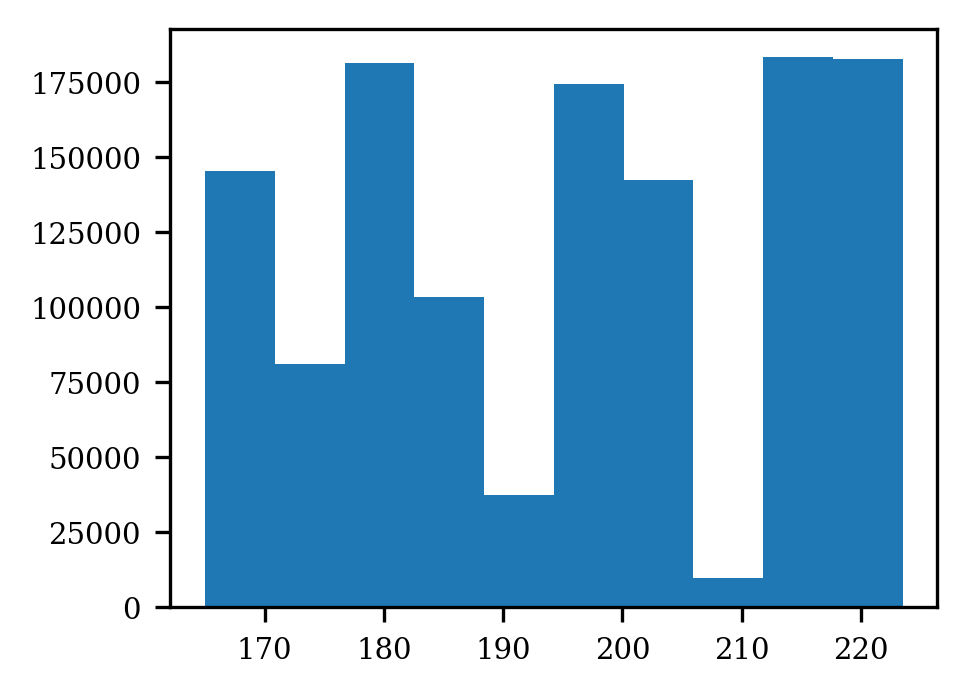

In [10]:
plt.hist(df["RA"])
#plt.hist(df_gama["RA"])

In [9]:
waves_mag_cols = ['total_ap_dust_Z_VISTA', 'total_ap_dust_Y_VISTA', 'total_ap_dust_J_VISTA', 'total_ap_dust_H_VISTA', 'total_ap_dust_K_VISTA','total_ap_dust_u_VST', 'total_ap_dust_g_VST', 'total_ap_dust_r_VST', 'total_ap_dust_i_VST']


In [10]:
# Conversion of flux to magnitude
def flux_to_mag(flux):
    return -2.5 * np.log10(flux) - 48.6

In [11]:
def mag_to_flux(mag):
    return 10 ** (-(mag + 48.6) / 2.5)

In [12]:
flux_columns = []
for i in waves_mag_cols:
    flux_columns.append(i+'_flux')
    df[i+'_flux'] = mag_to_flux(df[i])

In [13]:
df.columns

Index(['id_galaxy_sky', 'HaloID', 'RA', 'Dec', 'Z', 'zcos',
       'total_ap_dust_Z_VISTA', 'total_ab_dust_Z_VISTA',
       'total_ap_dust_Y_VISTA', 'total_ap_dust_J_VISTA',
       'total_ap_dust_H_VISTA', 'total_ap_dust_K_VISTA', 'total_ap_dust_u_VST',
       'total_ab_dust_u_VST', 'total_ap_dust_g_VST', 'total_ap_dust_r_VST',
       'total_ab_dust_r_VST', 'total_ap_dust_i_VST',
       'total_ap_dust_Z_VISTA_flux', 'total_ap_dust_Y_VISTA_flux',
       'total_ap_dust_J_VISTA_flux', 'total_ap_dust_H_VISTA_flux',
       'total_ap_dust_K_VISTA_flux', 'total_ap_dust_u_VST_flux',
       'total_ap_dust_g_VST_flux', 'total_ap_dust_r_VST_flux',
       'total_ap_dust_i_VST_flux'],
      dtype='object')

In [14]:
# Applying a 1% error to all fluxes
def apply_random_error(flux):
    error_factor = 0.05  
    noise = np.random.normal(loc=0, scale=error_factor * flux)
    return flux + noise

#flux_columns = ['lsst_r', 'lsst_u', 'lsst_g', 'lsst_i', 'lsst_z', 'lsst_y', 
#                '2mass_j', '2mass_h', '2mass_ks']


for col in tqdm(flux_columns):
    df[col] = df[col].apply(apply_random_error)

  0%|          | 0/9 [00:00<?, ?it/s]

In [15]:
# Converting flux to magnitudes
mag_cols=[]

for col in tqdm(flux_columns):
    mag_col = f'mag_{col}'  # New column name for magnitudes
    mag_cols.append(mag_col)
    df[mag_col] = df[col].apply(flux_to_mag)

  0%|          | 0/9 [00:00<?, ?it/s]

### photo-z estimation

In [18]:
# Creating X, the array of features needed for photo-z estimate

X=np.zeros((len(df),45))

l=0
for i in tqdm(range(len(mag_cols))):
    for j in range(i+1,len(mag_cols)):
        X[:,l]=(df[mag_cols[i]] - df[mag_cols[j]])
        l+=1
for mag in tqdm(mag_cols):
    X[:,l]=df[mag]
    l+=1

  0%|          | 0/9 [00:00<?, ?it/s]

  0%|          | 0/9 [00:00<?, ?it/s]

In [10]:
# Making of column of 0-N in the dataframe to be used later
df['raw_index']=range(len(df))

In [11]:
# Split the data into training and testing sets based on Right Ascension (RA)
# Note: df['raw_index'] was previously created with: df['raw_index'] = range(len(df))
print("Creating training and test sets based on RA coordinates...")
dftrain = df[(df['RA'] < 170)]
dftest = df[(df['RA'] > 170)]

Creating training and test sets based on RA coordinates...


In [ ]:
"""
Photometric Redshift Estimation using FlexCode
This script:
1. Prepares training and test datasets from astronomical survey data
2. Trains a conditional density estimation model using FlexCode with XGBoost
3. Predicts photometric redshifts and optimizes post-processing parameters
"""

import numpy as np
import flexcode
from flexcode.regression_models import XGBoost
from flexcode import post_processing
from sklearn import preprocessing
from tqdm import tqdm  # For progress bars


def print_section(title):
    """Helper function to print formatted section headers"""
    print(f"\n{'=' * 50}")
    print(f"    {title}")
    print(f"{'=' * 50}")


print_section("DATA PREPARATION")

# Split the data into training and testing sets based on Right Ascension (RA)
# Note: df['raw_index'] was previously created with: df['raw_index'] = range(len(df))
print("Creating training and test sets based on RA coordinates...")
dftrain = df[(df['RA'] < 170)]
dftest = df[(df['RA'] > 170)]

# Report dataset sizes
print(f"Training set size: {len(dftrain)} galaxies")
print(f"Test set size: {len(dftest)} galaxies")

# Extract feature matrices using the raw_index created earlier
print("Extracting feature matrices and spectroscopic redshifts...")
Xtrain = X[dftrain['raw_index']]
Xtest = X[dftest['raw_index']]  # Using proper test indices

# Scale features to have zero mean and unit variance
print("Scaling features...")
scaler = preprocessing.StandardScaler().fit(Xtrain)
Xtrain = scaler.transform(Xtrain)
Xtest = scaler.transform(Xtest)

# Extract spectroscopic redshift values (ground truth)
Ztrain = dftrain['Z'].values
Ztest = dftest['Z'].values

print(f"Feature matrix shapes - Training: {Xtrain.shape}, Testing: {Xtest.shape}")
print(f"Redshift vector shapes - Training: {Ztrain.shape}, Testing: {Ztest.shape}")

print_section("MODEL TRAINING")

# Split training data into actual training and validation sets (80/20 split)
n_obs = Xtrain.shape[0]
n_train = round(n_obs * 0.8)
n_validation = n_obs - n_train

# Randomly shuffle the training data
print(f"Splitting training data: {n_train} for training, {n_validation} for validation")
perm = np.random.permutation(n_obs)
Xtrain_final = Xtrain[perm[:n_train], :]
Ztrain_final = Ztrain[perm[:n_train]]
X_validation = Xtrain[perm[n_train:], :]
Z_validation = Ztrain[perm[n_train:]]

# Set up and train the FlexCode model with XGBoost as the regression method
print("Training FlexCode model with XGBoost regression...")
model = flexcode.FlexCodeModel(
    XGBoost, 
    max_basis=10, 
    basis_system='cosine',
    regression_params={"max_depth": 8}
)

# Fit the model on training data
model.fit(Xtrain_final, Ztrain_final)
print("Model fitted. Now tuning hyperparameters using validation data...")
model.tune(X_validation, Z_validation)
print("Model training complete!")

print_section("PREDICTION")

# Generate conditional density estimates for each test galaxy
print("Predicting conditional density estimates for test galaxies...")
cdes, z_grid = model.predict(Xtest, n_grid=1000)
print(f"Generated {cdes.shape[0]} conditional density estimates across {cdes.shape[1]} redshift grid points")

# Keep copies of the original CDEs for comparison and post-processing
print("Creating copies of density estimates for different post-processing methods...")
cdes_original = cdes.copy()
cdes_sharp = cdes.copy()

print_section("POST-PROCESSING OPTIMIZATION")

# Function to create appropriate samples for optimization
def create_optimization_samples(cdes_array, ztest_array, target_size=10000):
    """Create appropriate-sized samples for optimization procedures"""
    if len(cdes_array) > target_size:
        # If dataset is large, sample a subset
        sample_indices = np.random.choice(len(cdes_array), size=target_size, replace=False)
        cdes_sample = cdes_array[sample_indices]
        ztest_sample = ztest_array[sample_indices]
        print(f"Using {target_size} random samples for optimization")
    else:
        # If dataset is small, use all data
        cdes_sample = cdes_array
        ztest_sample = ztest_array
        print(f"Using all {len(cdes_array)} samples for optimization")
    return cdes_sample, ztest_sample

# Sample data for bump threshold optimization
print("Preparing for bump removal threshold optimization...")
cdes_sample, ztest_sample = create_optimization_samples(cdes, Ztest)

# Optimize the bump removal threshold
print("Optimizing the bump removal threshold...")
delta_grid = np.logspace(-1, 1, 50)  # Grid of potential thresholds
best_delta = post_processing.choose_bump_threshold(cdes_sample, z_grid, ztest_sample, delta_grid)
print(f"Optimal bump removal threshold: {best_delta}")

# Sample data for sharpening parameter optimization
print("Preparing for sharpening parameter optimization...")
cdes_sample, ztest_sample = create_optimization_samples(cdes, Ztest)

# Optimize the sharpening parameter
print("Optimizing the sharpening parameter...")
alpha_grid = np.logspace(-1, 1, 50)  # Grid of potential sharpening values
best_alpha = post_processing.choose_sharpen(cdes_sample, z_grid, ztest_sample, alpha_grid)
print(f"Optimal sharpening parameter: {best_alpha}")

print_section("APPLYING POST-PROCESSING")



# Apply bump removal to each density estimate
print("Applying bump removal to each density estimate...")
for i in tqdm(range(len(cdes_sharp))):
    post_processing._remove_bumps(cdes_sharp[i], best_delta)  # Using optimized delta
    
# Apply sharpening to each density estimate
print("Applying sharpening to each density estimate...")
for i in tqdm(range(len(cdes_sharp))):
    post_processing.sharpen(cdes_sharp[i], best_alpha)  # Using optimized alpha

# Normalize the density estimates after post-processing
print("Normalizing density estimates...")
for i in range(len(cdes_sharp)):
    post_processing.normalize(cdes_sharp[i])

print_section("COMPLETED")
print("Photometric redshift estimation pipeline completed successfully!")

# Additional analyses could be added here, such as:
# - Plot examples of CDEs
# - Calculate point estimates (e.g., mode of each CDE)
# - Evaluate accuracy metrics


    DATA PREPARATION
Creating training and test sets based on RA coordinates...
Training set size: 145300 galaxies
Test set size: 1095471 galaxies
Extracting feature matrices and spectroscopic redshifts...
Scaling features...
Feature matrix shapes - Training: (145300, 45), Testing: (1095471, 45)
Redshift vector shapes - Training: (145300,), Testing: (1095471,)

    MODEL TRAINING
Splitting training data: 116240 for training, 29060 for validation
Training FlexCode model with XGBoost regression...


/its/home/sp624/.conda/envs/main_env/lib/python3.10/site-packages/xgboost/training.py:183: UserWarning: [13:40:32] WARNING: /workspace/src/objective/regression_obj.cu:250: reg:linear is now deprecated in favor of reg:squarederror.
  bst.update(dtrain, iteration=i, fobj=obj)
/its/home/sp624/.conda/envs/main_env/lib/python3.10/site-packages/xgboost/training.py:183: UserWarning: [13:40:32] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "silent" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/its/home/sp624/.conda/envs/main_env/lib/python3.10/site-packages/xgboost/training.py:183: UserWarning: [13:40:32] WARNING: /workspace/src/objective/regression_obj.cu:250: reg:linear is now deprecated in favor of reg:squarederror.
  bst.update(dtrain, iteration=i, fobj=obj)
/its/home/sp624/.conda/envs/main_env/lib/python3.10/site-packages/xgboost/training.py:183: UserWarning: [13:40:32] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "silent" } are not used.

  bst.update(d

Model fitted. Now tuning hyperparameters using validation data...
Model training complete!

    PREDICTION
Predicting conditional density estimates for test galaxies...
Generated 1095471 conditional density estimates across 1000 redshift grid points
Creating copies of density estimates for different post-processing methods...

    POST-PROCESSING OPTIMIZATION
Preparing for bump removal threshold optimization...
Using 10000 random samples for optimization
Optimizing the bump removal threshold...


In [ ]:
np.save('cdes_sharp',cdes_sharp)

In [ ]:
np.save('cdes',cdes)

In [ ]:
np.save('z_grid',z_grid)

In [16]:
#cdes=np.load('cdes.npy')

In [11]:
cdes_sharp=np.load('/its/home/sp624/group_supplementation/scripts/cdes_sharp.npy')

In [12]:
z_grid=np.load('/its/home/sp624/group_supplementation/scripts/z_grid.npy')

Plotting example photometric redshift distributions...


NameError: name 'cdes' is not defined

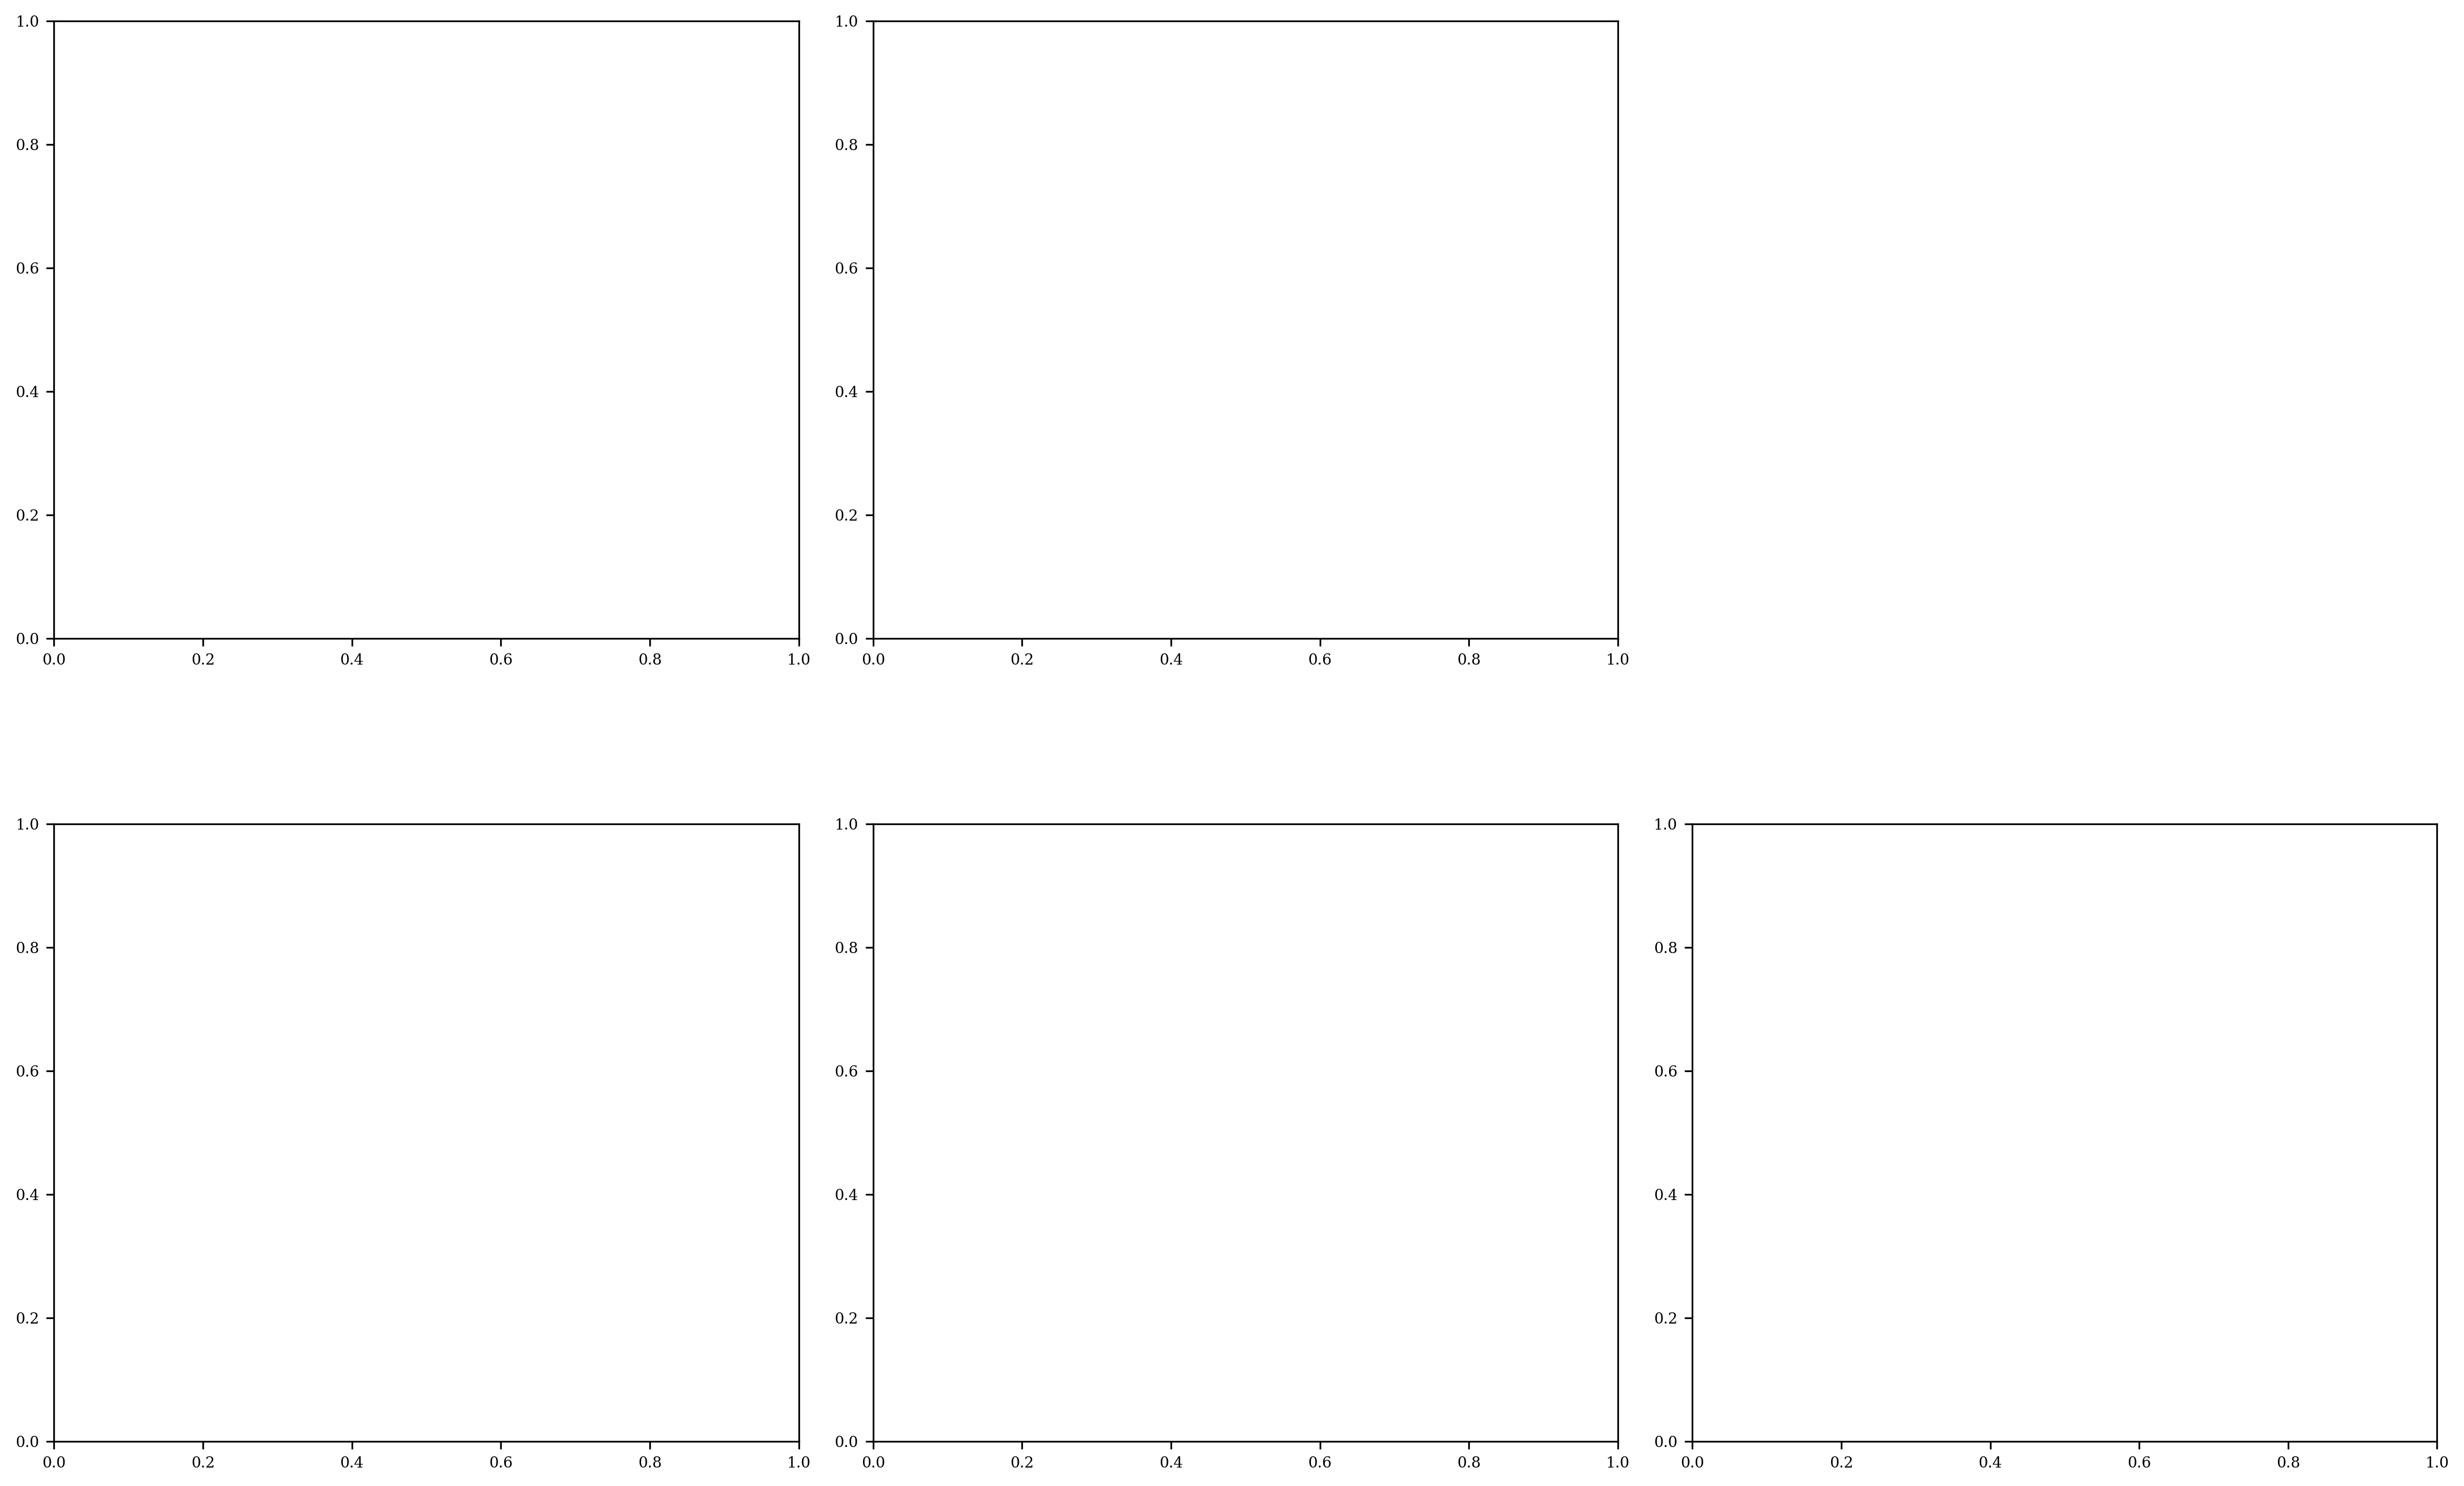

In [13]:

# Plotting example photometric redshift distributions
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import random
import numpy as np

def plot_example_redshifts():
    print("Plotting example photometric redshift distributions...")
    
    # Create figure and grid
    fig = plt.figure(figsize=(20, 12))
    spec = gridspec.GridSpec(ncols=3, nrows=2)
    plt.subplots_adjust(wspace=0.1, hspace=0.3)
    
    # Create subplots
    axes = [
        fig.add_subplot(spec[0, 0]),
        fig.add_subplot(spec[0, 1]),
        fig.add_subplot(spec[1, 0]),
        fig.add_subplot(spec[1, 1]),
        fig.add_subplot(spec[1, 2])
    ]
    
    # Get random sample of test galaxies
    # Ensure we're only selecting from our test indices
    test_indices = dftest['raw_index'].values
    sample_indices = random.sample(range(len(test_indices)), 5)
    sample_galaxies = [test_indices[i] for i in sample_indices]
    
    # Plot each sample
    for i, (ax, galaxy_idx) in enumerate(zip(axes, sample_galaxies)):
        # Find the position in our test array that corresponds to this galaxy
        cde_idx = np.where(dftest['raw_index'] == galaxy_idx)[0][0]
        
        # Plot the pre and post processed distributions
        ax.plot(z_grid, cdes[cde_idx], label='Pre-processing' if i == 0 else None)
        ax.plot(z_grid, cdes_sharp[cde_idx], label='Post-processing' if i == 0 else None)
        
        # Plot the true redshift
        true_z = dftest['Z'].iloc[cde_idx]
        ax.axvline(true_z, color="k", label='True $z$' if i == 0 else None, 
                  linewidth=2, linestyle='dashed')
        
        # Format the axes
        ax.set_yticks([])
        #ax.set_xticks([0, 0.1, 0.2, 0.3, 0.4, 0.5])
        ax.set_xlabel('$z$')
        ax.set_title(f'Galaxy ID = {galaxy_idx}', fontsize=18)
    
    # Add legend to the figure
    fig.legend(loc=(0.7, 0.8), frameon=False)
    
    # Save and show the figure
    plt.savefig('plots/photometric_redshifts.jpg', bbox_inches='tight', dpi=200)
    plt.show()
    
    print("Plot saved to 'plots/photometric_redshifts.jpg'")

# Call the plotting function
plot_example_redshifts()

In [ ]:
"""
Calculate point estimates (mode and mean) from the photometric redshift distributions.
This is a vectorized implementation to improve performance.
"""
import numpy as np
from tqdm import tqdm

def calculate_point_estimates():
    print("Calculating point estimates from photometric redshift distributions...")
    
    # Important: We need to work with the test set indices
    # Our cdes_sharp array corresponds to the dftest dataframe in the same order
    
    # Initialize arrays to store the results
    n_galaxies = len(dftest)
    zpredpeak = np.zeros(n_galaxies)
    zprednorm = np.zeros(n_galaxies)
    
    # Flatten z_grid for easier use
    z_grid_flat = z_grid[:, 0]
    
    # Vectorized calculation for the mean (expectation) of each distribution
    print("Calculating mean redshift for each galaxy...")
    # We can vectorize this calculation across all galaxies
    # This computes the weighted average (mean) of z values for each CDE
    z_grid_2d = z_grid_flat.reshape(1, -1)  # Shape (1, n_grid)
    weights_sum = np.sum(cdes_sharp, axis=1, keepdims=True)  # Shape (n_galaxies, 1)
    zprednorm = np.sum(z_grid_2d * cdes_sharp, axis=1) / weights_sum.flatten()
    
    # For the mode, we still need a loop since argmax is applied per distribution
    print("Calculating peak (mode) redshift for each galaxy...")
    for i in tqdm(range(n_galaxies)):
        # Find the index of the maximum value
        max_idx = np.argmax(cdes_sharp[i])
        # Get the corresponding redshift value
        zpredpeak[i] = z_grid_flat[max_idx]
    
    # Add the results to the test dataframe
    dftest['z_peak'] = zpredpeak
    dftest['z_mean'] = zprednorm
    
    # Calculate statistics about the estimates
    print("\nPoint estimate statistics:")
    print(f"Mean of peak estimates: {zpredpeak.mean():.4f}")
    print(f"Mean of expectation estimates: {zprednorm.mean():.4f}")
    print(f"Median of peak estimates: {np.median(zpredpeak):.4f}")
    print(f"Median of expectation estimates: {np.median(zprednorm):.4f}")
    
    # Calculate errors compared to spectroscopic redshifts
    z_spec = dftest['Z'].values
    peak_err = zpredpeak - z_spec
    mean_err = zprednorm - z_spec
    
    print(f"\nMean absolute error (peak): {np.abs(peak_err).mean():.4f}")
    print(f"Mean absolute error (mean): {np.abs(mean_err).mean():.4f}")
    print(f"Root mean square error (peak): {np.sqrt(np.mean(peak_err**2)):.4f}")
    print(f"Root mean square error (mean): {np.sqrt(np.mean(mean_err**2)):.4f}")
    
    return zpredpeak, zprednorm

# Call the function to calculate point estimates
zpredpeak, zprednorm = calculate_point_estimates()

Calculating point estimates from photometric redshift distributions...
Calculating mean redshift for each galaxy...


In [13]:
import numpy as np
from tqdm import tqdm

def calculate_point_estimates_lowmem():
    print("Calculating point estimates (low-memory mode)...")

    n_galaxies = len(dftest)
    zpredpeak = np.zeros(n_galaxies)
    zprednorm = np.zeros(n_galaxies)

    z_grid_flat = z_grid[:, 0]  # Shape (n_grid,)

    for i in tqdm(range(n_galaxies)):
        cde = cdes_sharp[i]
        total = np.sum(cde)
        if total == 0:
            zprednorm[i] = np.nan
            zpredpeak[i] = np.nan
            continue

        zprednorm[i] = np.sum(cde * z_grid_flat) / total
        zpredpeak[i] = z_grid_flat[np.argmax(cde)]

    # Attach results to the test DataFrame
    dftest['z_peak'] = zpredpeak
    dftest['z_mean'] = zprednorm

    print("\nPoint estimate statistics:")
    print(f"Mean of peak estimates: {np.nanmean(zpredpeak):.4f}")
    print(f"Mean of expectation estimates: {np.nanmean(zprednorm):.4f}")
    print(f"Median of peak estimates: {np.nanmedian(zpredpeak):.4f}")
    print(f"Median of expectation estimates: {np.nanmedian(zprednorm):.4f}")

    z_spec = dftest['Z'].values
    peak_err = zpredpeak - z_spec
    mean_err = zprednorm - z_spec

    print(f"\nMean absolute error (peak): {np.nanmean(np.abs(peak_err)):.4f}")
    print(f"Mean absolute error (mean): {np.nanmean(np.abs(mean_err)):.4f}")
    print(f"Root mean square error (peak): {np.sqrt(np.nanmean(peak_err**2)):.4f}")
    print(f"Root mean square error (mean): {np.sqrt(np.nanmean(mean_err**2)):.4f}")

    return zpredpeak, zprednorm

# Call the low-memory version
zpredpeak, zprednorm = calculate_point_estimates_lowmem()


Calculating point estimates (low-memory mode)...


100%|██████████| 1095471/1095471 [00:12<00:00, 86750.17it/s]
/tmp/ipykernel_3033736/3566188893.py:25: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dftest['z_peak'] = zpredpeak
/tmp/ipykernel_3033736/3566188893.py:26: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dftest['z_mean'] = zprednorm



Point estimate statistics:
Mean of peak estimates: 0.4024
Mean of expectation estimates: 0.4026
Median of peak estimates: 0.4013
Median of expectation estimates: 0.4021

Mean absolute error (peak): 0.0300
Mean absolute error (mean): 0.0291
Root mean square error (peak): 0.0403
Root mean square error (mean): 0.0386


In [14]:
dftest['Zpeak']=zpredpeak
dftest['Znorm']=zprednorm

/tmp/ipykernel_3033736/2344071028.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dftest['Zpeak']=zpredpeak
/tmp/ipykernel_3033736/2344071028.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dftest['Znorm']=zprednorm


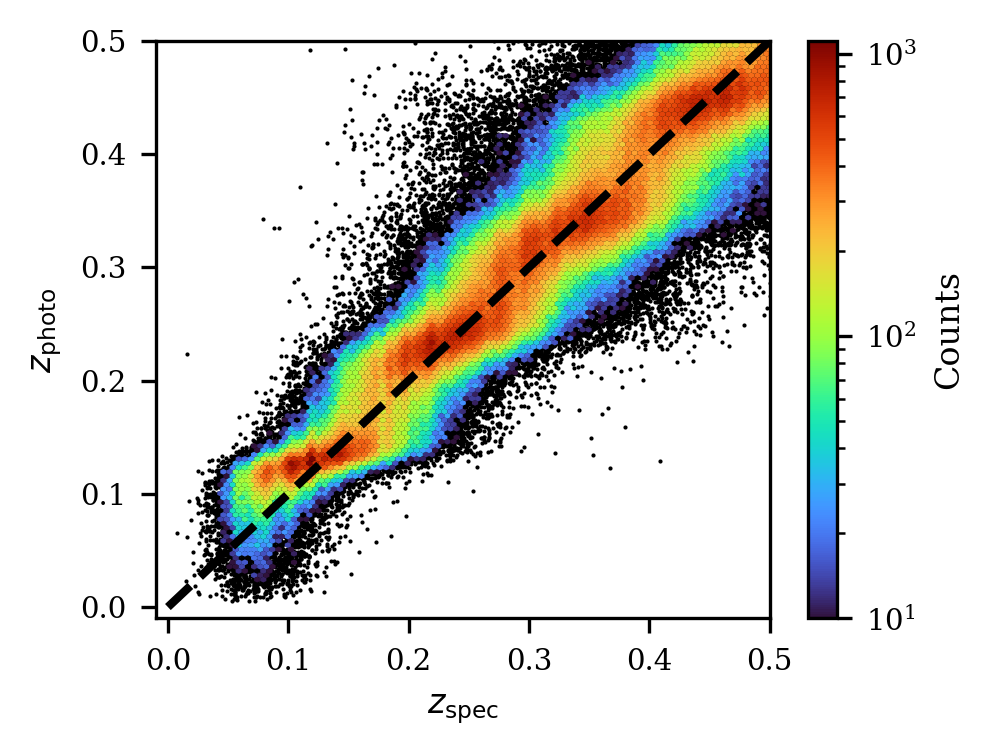

In [16]:
# Plotting the predicted z against the spec-z
import matplotlib
sample=dftest[(dftest['Zpeak']>0.004) & (dftest['Zpeak']<0.5)]
plt.scatter(sample['Z'],
            sample['Zpeak'],
            s=1,c='k',label='Galaxies',linewidth=0)
im=plt.hexbin(sample['Z'],sample['Zpeak'],gridsize=(100,round(100*2/3)),
              cmap='turbo',extent=(-0.01,0.5,-0.01,0.5),mincnt=10,linewidths=0,norm=matplotlib.colors.LogNorm())

plt.plot([0,0.5],[0,0.5],c='k',linestyle='dashed',linewidth=2)
plt.xlabel(r'$z_\mathrm{spec}$')#,fontsize=20)
plt.ylabel(r'$z_\mathrm{photo}$')#,fontsize=20)
plt.xlim(-0.01,0.5)
plt.ylim(-0.01,0.5)

cbar=plt.colorbar().set_label(label='Counts')
#im.figure.axes[1].tick_params(labelsize=20)

plt.savefig('plots/z_photo_z_spec.jpg',bbox_inches='tight',dpi=200)

plt.show()

In [17]:
# Median deviation from spec-z
np.median((sample['Zpeak']-sample['Z'])/(1+sample['Z']))

0.001041110131849984

In [18]:
# Median absolute deviation from spec-z
np.median(abs(sample['Zpeak']-sample['Z'])/(1+sample['Z']))

0.017548541032236464

In [19]:
# SMAD for photo-z mode
1.4826*np.median(abs(((sample['Zpeak']-sample['Z'])/(1+sample['Z'])) - 
                     np.median(((sample['Zpeak']-sample['Z'])/(1+sample['Z'])))))

0.026014954437619205

In [20]:
# SMAD for photo-z mean
1.4826*np.median(abs(((sample['Znorm']-sample['Z'])/(1+sample['Z'])) - 
                     np.median(((sample['Znorm']-sample['Z'])/(1+sample['Z'])))))

0.025778883435452888

### Halo properties

In [33]:
#Finding group centres from sharks
import numpy as np
import pandas as pd
from astropy import units as u
from astropy.cosmology import FlatLambdaCDM
from astropy.cosmology import z_at_value
from astropy.cosmology import default_cosmology

# Custom cosmology
cosmo = FlatLambdaCDM(H0=67.51, Om0=0.3)

def radec_to_xyz(ra_deg, dec_deg, redshift):
    """
    Convert RA, Dec, redshift to 3D comoving Cartesian coordinates.
    """
    ra_rad = np.deg2rad(ra_deg)
    dec_rad = np.deg2rad(dec_deg)
    r = cosmo.comoving_distance(redshift).to(u.Mpc).value
    x = r * np.cos(dec_rad) * np.cos(ra_rad)
    y = r * np.cos(dec_rad) * np.sin(ra_rad)
    z = r * np.sin(dec_rad)
    return np.stack([x, y, z], axis=-1)

def xyz_to_radec(xyz):
    """
    Convert 3D Cartesian coordinates back to RA, Dec, and comoving distance.
    """
    x, y, z = xyz.T
    r = np.sqrt(x**2 + y**2 + z**2)
    dec = np.arcsin(z / r)
    ra = np.arctan2(y, x)
    return np.rad2deg(ra) % 360, np.rad2deg(dec), r

def compute_group_geometric_centers(df):
    """
    Compute geometrically weighted centers of galaxy groups using 3D positions.
    """
    df = df.copy()
    df['luminosity'] = 10**(0.4 *(4.51- df['total_ab_dust_Z_VISTA'])) * 0.6751 / (10**14 )
    
    # Convert to 3D comoving coordinates
    xyz = radec_to_xyz(df['RA'].values, df['Dec'].values, df['Z'].values)
    df[['x', 'y', 'z']] = xyz

    group_centers = []

    for group_id, group in df.groupby('HaloID'):
        L = group['luminosity'].values
        log_xyz = np.log(group[['x', 'y', 'z']].values + 1e-30)  # avoid log(0)
        weighted_log_xyz = np.average(log_xyz, weights=L, axis=0)
        geo_center_xyz = np.exp(weighted_log_xyz)

        # Convert back to RA, Dec, comoving distance
        ra_c, dec_c, r_c = xyz_to_radec(geo_center_xyz[None, :])
        with default_cosmology.set(cosmo):
            z_c = float(z_at_value(cosmo.comoving_distance, r_c[0] * u.Mpc))

        group_centers.append({
            'group_id': group_id,
            'RA_center': ra_c[0],
            'Dec_center': dec_c[0],
            'z_center': z_c,
            'total_luminosity': L.sum()
        })

    return pd.DataFrame(group_centers)

In [34]:
group_centers = compute_group_geometric_centers(dftest)

/tmp/ipykernel_3041843/3844188440.py:49: RuntimeWarning: invalid value encountered in log
  log_xyz = np.log(group[['x', 'y', 'z']].values + 1e-30)  # avoid log(0)
Precision nan reached after 3 function calls. [astropy.cosmology.funcs.optimize]
/tmp/ipykernel_3041843/3844188440.py:49: RuntimeWarning: invalid value encountered in log
  log_xyz = np.log(group[['x', 'y', 'z']].values + 1e-30)  # avoid log(0)
Precision nan reached after 3 function calls. [astropy.cosmology.funcs.optimize]
/tmp/ipykernel_3041843/3844188440.py:49: RuntimeWarning: invalid value encountered in log
  log_xyz = np.log(group[['x', 'y', 'z']].values + 1e-30)  # avoid log(0)
Precision nan reached after 3 function calls. [astropy.cosmology.funcs.optimize]
/tmp/ipykernel_3041843/3844188440.py:49: RuntimeWarning: invalid value encountered in log
  log_xyz = np.log(group[['x', 'y', 'z']].values + 1e-30)  # avoid log(0)
Precision nan reached after 3 function calls. [astropy.cosmology.funcs.optimize]
/tmp/ipykernel_30418

KeyboardInterrupt: 

In [23]:
dftest.head()

,id_galaxy_sky,HaloID,RA,Dec,Z,zcos,mvir_hosthalo,mvir_subhalo,total_ap_dust_Z_VISTA,total_ab_dust_Z_VISTA,total_ap_dust_Y_VISTA,total_ap_dust_J_VISTA,total_ap_dust_H_VISTA,total_ap_dust_K_VISTA,total_ap_dust_u_VST,total_ab_dust_u_VST,total_ap_dust_g_VST,total_ap_dust_r_VST,total_ab_dust_r_VST,total_ap_dust_i_VST,raw_index
16,6422,61800000037,181.337265,-0.996625,0.973385,0.975788,2.272888e+12,2.260712e+12,20.563364,-23.338165,20.473047,20.287722,20.058302,19.882723,22.161482,-21.890423,21.997799,21.698124,-23.064199,21.108395,0
61,24036,58500000002,197.984726,-1.155843,0.978784,0.983071,6.288464e+12,6.235997e+12,20.946516,-23.294958,20.741854,20.437962,20.125431,19.906176,23.373003,-21.342548,23.063786,22.392962,-22.924812,21.660042,3
64,24184,58500000055,200.630783,-0.618883,0.973340,0.975176,4.630785e+12,7.796934e+11,20.231253,-23.233894,20.257456,20.229166,20.139952,20.072531,20.631134,-22.615042,20.715986,20.800034,-23.128849,20.514988,4
67,25873,24820800000004,215.339890,2.586337,0.711633,0.714915,7.108449e+11,7.044249e+11,20.713692,-22.560389,20.487070,20.289948,19.990795,19.866999,22.488741,-20.922943,22.261803,21.594456,-22.217983,20.880402,5
71,25993,24826000000010,175.987976,1.190220,0.690554,0.692815,2.489617e+12,2.048854e+12,20.927195,-22.483225,20.636660,20.345764,19.978559,19.815214,24.239056,-20.227324,23.297064,22.087749,-22.013901,21.217731,6


In [74]:
# Initialising an r<19.8 magnitude limited subset
df19=df[df['Rpetro']<19.8].copy()

In [75]:
# Initialising the groups (haloes) from the r<19.8 subset.
# Worth noting that galaxy_id==0 in FS2 means it is the halo centre
haloes=df19[df19['galaxy_id']==0]['HaloID'].values

In [76]:
H0 = cosmo.H(0)
h=H0.value/100

In [77]:
# Creating the halo catalogue with properties
dfHalo=pd.DataFrame(index=df.groupby('HaloID').size().index)

dfHalo['N']=df19.groupby('HaloID').size()
dfHalo['Mass']=10**df.groupby('HaloID').mean()['lm_halo']
dfHalo=dfHalo.loc[haloes]
dfHalo['RA']=df19[df19['galaxy_id']==0]['RA'].values
dfHalo['Dec']=df19[df19['galaxy_id']==0]['Dec'].values
dfHalo['Z']=df19[df19['galaxy_id']==0]['Z'].values
dfHalo['Centre']=df19[df19['galaxy_id']==0].index
dfHalo['Distance']=(cosmo.comoving_distance(dfHalo['Z']).value)*1e6*h
dfHalo=dfHalo[dfHalo['N']>1].copy()

#N21 is the number of r<21 mmembers of each halo
dfHalo['N21']=df.groupby('HaloID').size().loc[dfHalo.index]

In [82]:
# Defining r_200 and v_200 
def H(z):
    return cosmo.H(z).value

dfHalo['H']=dfHalo['Z'].apply(H)

from astropy.constants import G
GMpc = G.to(u.M_sun**-1 * u.km**2 * u.s**-2 * u.Mpc).value
Gpc = G.to(u.M_sun**-1 * u.km**2 * u.s**-2 * u.pc).value

delta=200

dfHalo['r_200']=(((2*GMpc*dfHalo['Mass'])/(delta * dfHalo['H']**2))**(1/3))*1e6

dfHalo['v_200']=10*dfHalo['H']*dfHalo['r_200']/1e3

dfHalo['Ang_link']=dfHalo['r_200']/dfHalo['Distance']

In [83]:
# Recessional velocities of galaxies and groups (we do supplementation in velocity, not redshift space)
from astropy.constants import c
C=c.value

dfHalo['V'] = (cosmo.H0*cosmo.comoving_distance(np.array(dfHalo['Z']))).value/(1+dfHalo['Z'])*1e3

df['V']=(cosmo.H0*cosmo.comoving_distance(np.array(df['Zpeak']))).value/(1+df['Zpeak'])*1e3

### Establishing halo profile

In [84]:
# Creating a dataframe of just 19.8 < r < 21 outside the magnitude limit of spectro
dfphoto=df.drop(df19.index)

In [85]:
# Creating KDtrees of groups and galaxies in angular and velocity space
import math
from sklearn.neighbors import KDTree

dfHalo['DecRad'] = (dfHalo['Dec']).apply(math.radians)
dfHalo['RARad'] = (dfHalo['RA']).apply(math.radians)
dfphoto['DecRad'] = (dfphoto['Dec']).apply(math.radians)
dfphoto['RARad'] = (dfphoto['RA']).apply(math.radians)

ANG_halo=np.array(list(zip(dfHalo['RARad'],dfHalo['DecRad'])))
ANGTree_halo=KDTree(ANG_halo, leaf_size=2) 

ANG_gal=np.array(list(zip(dfphoto['RARad'],dfphoto['DecRad'])))
ANGTree_gal=KDTree(ANG_gal, leaf_size=2) 

VEL_halo=np.array(list(zip(dfHalo['V'])))
VELTree_halo=KDTree(VEL_halo, leaf_size=2) 

VEL_gal=np.array(list(zip(dfphoto['V'])))
VELTree_gal=KDTree(VEL_gal, leaf_size=2) 

In [94]:
dfHalo['raw_index']=range(len(dfHalo))

In [115]:
# Using KDtrees to find all photometric galaxies within 3 R_200 and 40 V_200 of each halo
# This comes in the form of a dictionary called groups

groups={}

for halo in tqdm(dfHalo.index):
    
    ANGind = ANGTree_gal.query_radius(ANG_halo[[int(dfHalo.loc[halo]['raw_index'])]], r=3*dfHalo['Ang_link'][halo])
    
    if len(ANGind[0])>0:
        VELtree = KDTree(VEL_gal[ANGind[0]], leaf_size=2)
        ind = VELtree.query_radius(VEL_halo[[int(dfHalo.loc[halo]['raw_index'])]], r=40*dfHalo['v_200'][halo])
        groups[halo]=(dfphoto.iloc[ANGind[0]]).iloc[ind[0]].index.values
    else:
        groups[halo]=[]

  0%|          | 0/37279 [00:00<?, ?it/s]

In [118]:
# Defining angular separation functio
def angsep(lon1, lat1, lon2, lat2):

    sdlon = np.sin(lon2 - lon1)
    cdlon = np.cos(lon2 - lon1)
    slat1 = np.sin(lat1)
    slat2 = np.sin(lat2)
    clat1 = np.cos(lat1)
    clat2 = np.cos(lat2)

    num1 = clat2 * sdlon
    num2 = clat1 * slat2 - slat1 * clat2 * cdlon
    denominator = slat1 * slat2 + clat1 * clat2 * cdlon

    return np.arctan2(np.hypot(num1, num2), denominator)

In [119]:
df19['RARad']=df19['RA']*(np.pi/180)
df19['DecRad']=df19['Dec']*(np.pi/180)

In [120]:
# Next we'll be making a dataframe called probdf
# The purpose of this dataframe is to keep track of all halo-galaxy associations

In [121]:
# This loop goes through the groups dictionary we just made
# It then makes a list of the halo in the association, the galaxy, their velocity and radial difference, and whether the match is true or not

halos=[]
gals=[]
vel_diff=[]
rad_diff=[]
is_match=[]

for halo in tqdm((groups)):
    for gal in groups[halo]:
        halos.append(halo)
        gals.append(gal)
        vel_diff.append(abs(dfHalo['V'][halo] - dfphoto['V'][gal])/dfHalo['v_200'][halo])
        rad_diff.append((angsep(df19.loc[dfHalo.loc[halo]['Centre']]['RARad'],df19.loc[dfHalo.loc[halo]['Centre']]['DecRad'],
                                dfphoto.loc[gal]['RARad'],dfphoto.loc[gal]['DecRad']))/dfHalo['Ang_link'][halo])
        if df.loc[gal]['HaloID']==halo:
            is_match.append(True)
        else:
            is_match.append(False)

  0%|          | 0/37279 [00:00<?, ?it/s]

In [122]:
# Adding the columns to the probdf dataframe

probdf=pd.DataFrame()
probdf['halo']=halos
probdf['gal']=gals
probdf['vel_diff']=vel_diff
probdf['rad_diff']=rad_diff
probdf['match']=is_match

In [343]:
probdf

,halo,gal,vel_diff,rad_diff,match,spline_prob,sharp_spline_prob
0,4140350315655,13560662,39.793060,1.211562,False,0.014128,0.012659
1,4140350315655,24527240,39.355100,2.006175,False,0.004920,0.003094
2,4140350315655,25303708,38.918672,0.191882,False,0.199736,0.175836
3,4140350315655,24322196,39.355100,0.911626,False,0.040961,0.029121
4,4140350315655,21742893,38.339143,2.726865,False,0.000000,0.000000
...,...,...,...,...,...,...,...
1856754,3941360527594,264118,34.739260,1.111436,False,0.072139,0.042795
1856755,3941360527594,172333,34.739260,2.984183,False,0.000000,0.000000
1856756,3941360527594,282127,34.739260,1.848313,False,0.022479,0.013536
1856757,3941360527594,2624542,34.739260,2.870297,False,0.000000,0.000000


In [322]:
# Here we make our halo profile
# This is done by measuring the fraction of true galaxy-halo associations at each r/r_200 and v/v_200

n=20

r_range=np.linspace(0,3,n+1)
vel_range=np.linspace(0,40,n+1)
r_centres=(r_range[:-1] + r_range[1:]) / 2
vel_centres=(vel_range[:-1] + vel_range[1:]) / 2

r=[]
vel=[]
fracs=[]


frac_arr=np.zeros((n,n))

for i in tqdm(range(len(r_centres))):
    for j in range(len(vel_centres)):
        probdf_lim=probdf[(probdf['rad_diff'] > r_range[i]) & (probdf['rad_diff'] < r_range[i+1]) & (probdf['vel_diff'] > vel_range[j]) & (probdf['vel_diff'] < vel_range[j+1])]
        if len(probdf_lim)>0:          
            frac=(len(probdf_lim[probdf_lim['match']==True])/len(probdf_lim))
            frac_arr[j,i]=frac
            r.append(r_centres[i])
            vel.append(vel_centres[j])
            fracs.append(frac)

  0%|          | 0/20 [00:00<?, ?it/s]

In [323]:
# Saving the halo profile, as we'll be using it for GAMA supplementation
np.save('fracs',fracs)
np.save('r',r)
np.save('vel',vel)

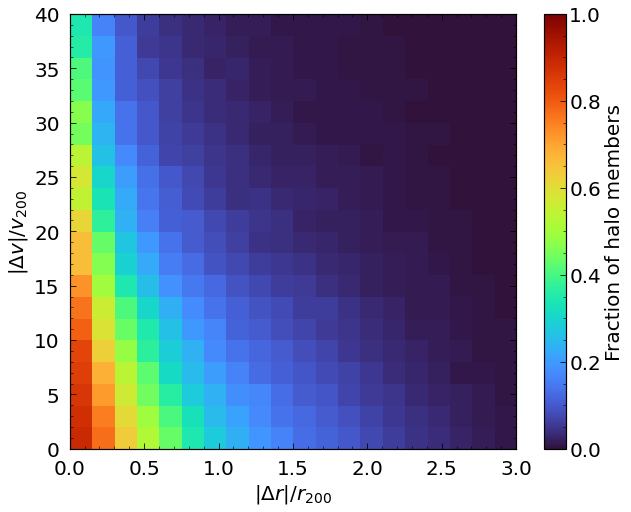

In [324]:
# Visualsing the halo profile

from matplotlib.colors import LogNorm

im=plt.imshow(frac_arr,extent=[min(r_range),max(r_range),max(vel_range),min(vel_range)],
           aspect='auto',cmap='turbo')
cbar=plt.colorbar().set_label(label='Fraction of halo members')
im.figure.axes[1].tick_params()
plt.gca().invert_yaxis()


plt.clim(0,1)
plt.axvline(0,c='k',linewidth=1,linestyle='dashed')
plt.xlabel('$ | \Delta r | /r_{200}$')
plt.ylabel('$ | \Delta v | / v_{200}}$')
plt.tick_params(axis='x', which='major', pad=10)
plt.tick_params(axis='y', which='major', pad=10)

#plt.savefig('v_200_r_200.jpg', bbox_inches='tight', dpi=200)

plt.show()

In [348]:
# Now we'll use scipy to interpolate between the 20 x 20 grid to make a spline
import scipy as sp
import scipy.interpolate

spline = sp.interpolate.Rbf(r,vel,fracs,smooth=0.2)

r_grid=np.linspace(0,3,100)
vel_grid=np.linspace(0,40,100)
r_mesh, vel_mesh = np.meshgrid(r_grid, vel_grid, indexing='xy')
Z = np.zeros((np.array(r).size, np.array(vel).size))

Z = spline(r_mesh,vel_mesh)


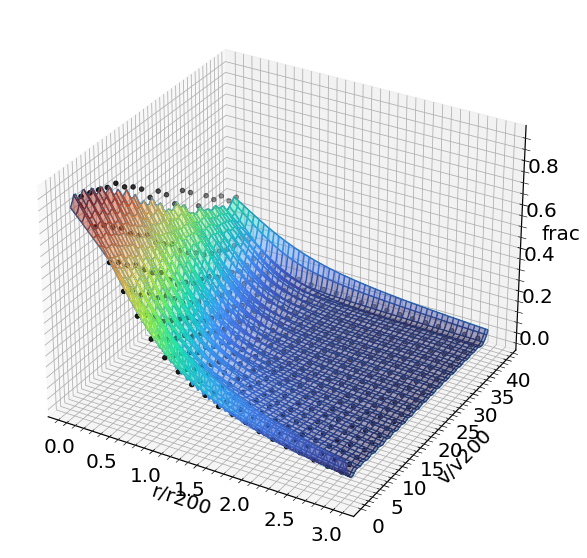

In [349]:
#Plotting the spline and the 20 x 20 grid previously in 3D

from mpl_toolkits.mplot3d import axes3d

from matplotlib import cm
plt.figure(figsize=(10,10))
ax = plt.axes(projection='3d')
ax.plot_wireframe(r_mesh, vel_mesh, Z.reshape(100,100))
ax.plot_surface(r_mesh, vel_mesh, Z.reshape(100,100),alpha=0.4,
                cmap=cm.turbo,linewidth=0, antialiased=False)
ax.scatter3D(r,vel,fracs,c='k')
ax.set_xlabel('r/r200')
ax.set_ylabel('v/v200')
ax.set_zlabel('frac')

#plt.savefig('spline.jpg',overwrite=True)

plt.show()

### Calculating galaxy-halo association probability

In [134]:
df['RARad']=(np.pi/180)*df['RA']
df['DecRad']=(np.pi/180)*df['Dec']

In [155]:
# Here's where we find the probability of each galaxy-halo association
# We do this by iterating through probdf
# This takes in the order of a couple of hours
spline_prob=[]
spline_sharp_prob=[]
vel_array=(cosmo.H0*cosmo.comoving_distance(z_grid)).value/(1+z_grid)*1e3
for ix in tqdm(probdf.index):
    halo=probdf['halo'][ix]
    gal=probdf['gal'][ix]
    index=df['raw_index'][gal]
    
    # Extracting angular difference between halo and galaxy
    ang_diff=probdf.loc[ix]['rad_diff']
    
    # Creating an array of deviation from halo velocity 
    vel_diff_array=abs(dfHalo['V'][halo]-vel_array)/dfHalo['v_200'][halo]
    
    # Creating the PDF of halo velocity given the ang_diff and the profile created earlier
    spline_array=spline(ang_diff*np.ones(len(vel_diff_array[vel_diff_array<40])),
                        vel_diff_array[vel_diff_array<40])
    
    #Multplying the PDF of halo velocity with cdes, the galaxy p(z) and then normalising
    spline_prob.append(sum(spline_array*cdes[index][vel_diff_array[:,0]<40]/sum(cdes[index])))
    
    #Same for post processed p(z)
    spline_sharp_prob.append(sum(spline_array*cdes_sharp[index][vel_diff_array[:,0]<40]/sum(cdes_sharp[index])))

  0%|          | 0/1856759 [00:00<?, ?it/s]

In [156]:
# Adding probabilities to porobdf
probdf['spline_prob']=spline_prob
probdf['sharp_spline_prob']=spline_sharp_prob

In [157]:
#Setting probabilities that are less than 0 to 0

probdf['sharp_spline_prob']=probdf['sharp_spline_prob'].clip(lower=0)
probdf['spline_prob']=probdf['spline_prob'].clip(lower=0)

In [351]:
probdf

,halo,gal,vel_diff,rad_diff,match,spline_prob,sharp_spline_prob
0,4140350315655,13560662,39.793060,1.211562,False,0.014128,0.012659
1,4140350315655,24527240,39.355100,2.006175,False,0.004920,0.003094
2,4140350315655,25303708,38.918672,0.191882,False,0.199736,0.175836
3,4140350315655,24322196,39.355100,0.911626,False,0.040961,0.029121
4,4140350315655,21742893,38.339143,2.726865,False,0.000000,0.000000
...,...,...,...,...,...,...,...
1856754,3941360527594,264118,34.739260,1.111436,False,0.072139,0.042795
1856755,3941360527594,172333,34.739260,2.984183,False,0.000000,0.000000
1856756,3941360527594,282127,34.739260,1.848313,False,0.022479,0.013536
1856757,3941360527594,2624542,34.739260,2.870297,False,0.000000,0.000000


/its/home/tc339/.conda/envs/env/lib/python3.8/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


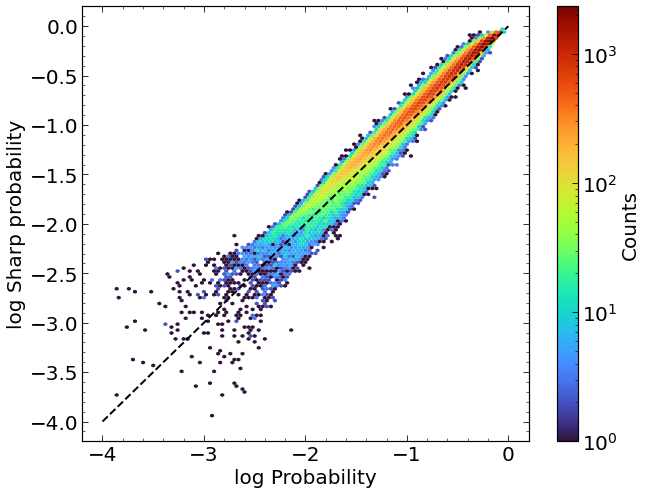

In [164]:
# Plot comparing the processed probabilities with the unprocessed probabilities
im=plt.hexbin(np.log10(probdf[probdf['match']==True]['spline_prob']),
              np.log10(probdf[probdf['match']==True]['sharp_spline_prob']),
              gridsize=(100,round(100*2/3)),cmap='turbo',extent=(-4,0,-4,0),
              mincnt=1,linewidths=0,norm=matplotlib.colors.LogNorm())
plt.plot([-4,0],[-4,0],c='k',linestyle='dashed',linewidth=2)

cbar=plt.colorbar().set_label(label='Counts',fontsize=20)
im.figure.axes[1].tick_params(labelsize=20)
plt.xlabel('log Probability')
plt.ylabel('log Sharp probability')
plt.show()

plt.show()

In [185]:
# These two cells are just for plotting an example galaxy-halo association
# In this case, we're looking at a random association from probdf with a >0.9 probability

ix=random.choice(probdf[probdf['sharp_spline_prob']>0.9].index)
halo=probdf['halo'][ix]
gal=probdf['gal'][ix]
index=dfphoto['raw_index'][gal]
ang_diff=angsep(df19.loc[dfHalo.loc[halo]['Centre']]['RARad'],df19.loc[dfHalo.loc[halo]['Centre']]['DecRad'],dfphoto.loc[gal]['RARad'],dfphoto.loc[gal]['DecRad'])/dfHalo['Ang_link'][halo]
vel_array=(cosmo.H0*cosmo.comoving_distance(z_grid)).value/(1+z_grid)*1e3
vel_diff_array=abs(dfHalo['V'][halo]-vel_array)/dfHalo['v_200'][halo]
spline_array=spline(ang_diff*np.ones(len(vel_diff_array[vel_diff_array<15])),vel_diff_array[vel_diff_array<15])
sharp_prob=probdf['sharp_spline_prob'][ix]
prob=probdf['spline_prob'][ix]

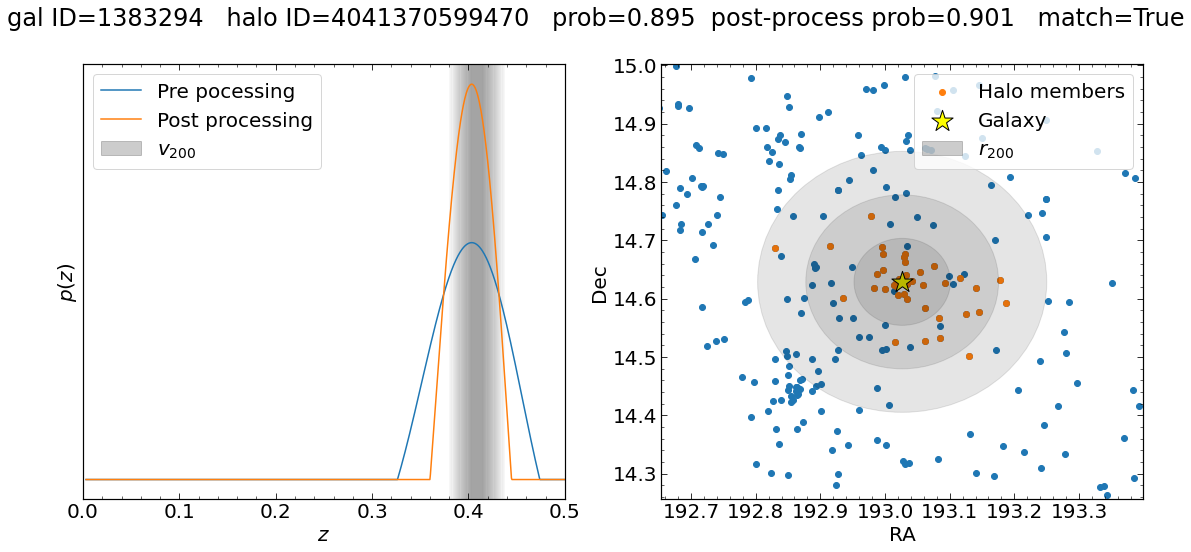

In [201]:
fig, ax = plt.subplots(1,2, facecolor='w', edgecolor='k',gridspec_kw={'width_ratios': [1, 1]},figsize=(19,8))
fig.subplots_adjust( wspace=0.2)
axs=ax.ravel()

from astropy.constants import c
v_grid=np.linspace(1,5,20)
r_grid=np.linspace(1,3,3)

for v in v_grid:
    axs[0].axvspan(dfHalo['Z'][halo]-v*(dfHalo['v_200'][halo]*(1+dfHalo['Z'][halo])/c.to(u.m/u.s).value),
                dfHalo['Z'][halo]+v*(dfHalo['v_200'][halo]*(1+dfHalo['Z'][halo])/c.to(u.m/u.s).value),
                alpha=0.02, color='black')
axs[0].plot(z_grid,cdes[index]/np.trapz(cdes[index]),label='Pre pocessing')
axs[0].plot(z_grid,cdes_sharp[index]/np.trapz(cdes_sharp[index]),label='Post processing')

axs[0].axvspan(-2,-1,alpha=0.2, color='black',label='$v_{200}$')
            

axs[0].set_xlabel('$z$')
axs[0].set_ylabel('$p(z)$')
axs[0].set_yticks([])
axs[0].set_xlim(0,0.5)
#plt.title('prob='+str(round(prob,3))+ '  post-process prob=' +str(round(sharp_prob,3))+'   match='+str(probdf['match'][ix]))
axs[0].legend(frameon=True)

sample=df[(df['Z']>dfHalo['Z'][halo]-3*(dfHalo['v_200'][halo]*(1+dfHalo['Z'][halo])/c.to(u.m/u.s).value)) &
          (df['Z']<dfHalo['Z'][halo]+3*(dfHalo['v_200'][halo]*(1+dfHalo['Z'][halo])/c.to(u.m/u.s).value))]


axs[1].scatter(sample['RA'],
            sample['Dec'])
axs[1].scatter(df[df['HaloID']==halo]['RA'],df[df['HaloID']==halo]['Dec'],label='Halo members')

axs[1].scatter(dfphoto.loc[gal]['RA'],dfphoto.loc[gal]['Dec'],c='yellow',marker='*',edgecolors='black',s=500,
              label='Galaxy')


for r in r_grid:
    circle=plt.Circle((dfHalo['RA'][halo],dfHalo['Dec'][halo]), 
                       r*(180/np.pi)*dfHalo['r_200'][halo]/dfHalo['Distance'][halo], 
                       color='black',alpha=0.1)
    axs[1].add_patch(circle)

circle=plt.Circle((-100,-100),r*(180/np.pi)*dfHalo['r_200'][halo]/dfHalo['Distance'][halo], 
                       color='black',alpha=0.2,label='$r_{200}$')
axs[1].add_patch(circle)


axs[1].set_xlim(dfHalo['RA'][halo]-5*(180/np.pi)*dfHalo['r_200'][halo]/dfHalo['Distance'][halo],
        dfHalo['RA'][halo]+5*(180/np.pi)*dfHalo['r_200'][halo]/dfHalo['Distance'][halo])
axs[1].set_ylim(dfHalo['Dec'][halo]-5*(180/np.pi)*dfHalo['r_200'][halo]/dfHalo['Distance'][halo],
        dfHalo['Dec'][halo]+5*(180/np.pi)*dfHalo['r_200'][halo]/dfHalo['Distance'][halo])
axs[1].set_xlabel('RA')
axs[1].set_ylabel('Dec')
axs[1].legend(frameon=True)
plt.suptitle('gal ID='+str(gal)+'   halo ID='+str(halo)+'   prob='+str(round(prob,3))+ '  post-process prob=' +str(round(sharp_prob,3))+
             '   match='+str(probdf['match'][ix]))

plt.savefig('plots/prob_example.jpg',bbox_inches='tight',dpi=200)

plt.show()


In [188]:
# Median probabilities of TRUE assocations
print(np.median(probdf[probdf['match']==True]['spline_prob']))
print(np.median(probdf[probdf['match']==True]['sharp_spline_prob']))

0.21555285203096086
0.26144721314951713


In [190]:
# Median probabilities of FALSE assocations
print(np.median(probdf[probdf['match']==False]['spline_prob']))
print(np.median(probdf[probdf['match']==False]['sharp_spline_prob']))

0.0174685529478183
0.018543547148370636


### Optimising threshold probability

In [198]:
# Calculating the F1 score as a function of probability
probs_arr=np.logspace(-3,0,100)

f1_arr=[]
for i in tqdm(probs_arr):
    TP=len(probdf[(probdf['sharp_spline_prob']>i) & (probdf['match']==True)])
    FP=len(probdf[(probdf['sharp_spline_prob']>i) & (probdf['match']==False)])
    FN=len(probdf[(probdf['sharp_spline_prob']<i) & (probdf['match']==True)])
    f1_arr.append(2*TP/(2*TP + FN + FP))

  0%|          | 0/100 [00:00<?, ?it/s]

In [199]:
# threshold is the probability at which the F1 score is maximised
threshold=probs_arr[f1_arr.index(max(f1_arr))]
print(threshold)

0.24770763559917114


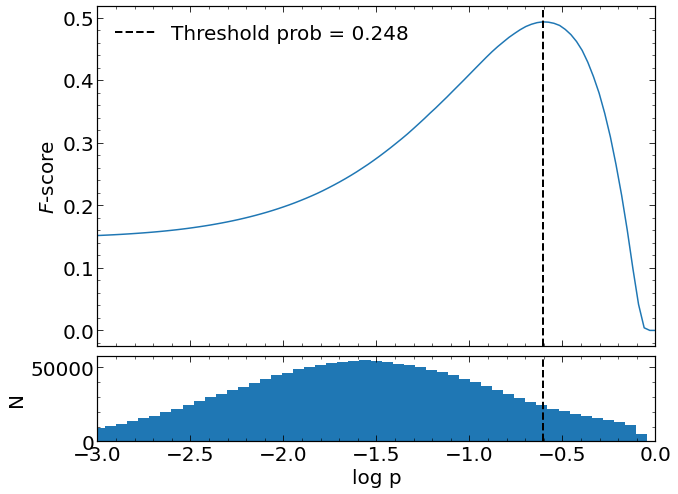

In [205]:
# Plotting the F1 score as a function of probability
fig, axs = plt.subplots(2,1, facecolor='w', edgecolor='k',gridspec_kw={'height_ratios': [4, 1]})
fig.subplots_adjust(hspace = 0.05, wspace=0)

axs[0].plot(np.log10(probs_arr),f1_arr)
axs[0].xaxis.set_ticklabels([])
axs[0].set_ylabel(r'$F$'+'-score')
axs[0].set_xlim(-3,0)
axs[0].axvline(np.log10(threshold),c='k',linewidth=2,linestyle='dashed',label='Threshold prob = '+str(round(threshold,3)))
axs[0].legend(frameon=False)

axs[1].hist(np.log10(probdf[probdf['sharp_spline_prob']>1e-6]['sharp_spline_prob']),bins=100)
axs[1].axvline(np.log10(threshold),c='k',linewidth=2,linestyle='dashed')
axs[1].set_xlim(-3,0)
axs[1].set_xlabel('log p')
axs[1].set_ylabel('N')

plt.savefig('plots/F1_prob.jpg',bbox_inches='tight',dpi=200)

plt.show()

### photo-z refinement (z-tag)

In [210]:
# Creating a z_tag column for photometric galaxies full of NaNs initially
dfphoto['Z_tag']=np.NAN

In [213]:
# Iterating through probdf, and appending z_tag if the probability is greater than the threshold
# probdf is sorted by probability here, meaning that with multiple associations, the higher prob takes precedence
for i in tqdm(probdf.sort_values('sharp_spline_prob').index):
    if probdf.loc[i]['sharp_spline_prob']>threshold:
        gal_id = probdf.loc[i]['gal']
        halo_id = probdf.loc[i]['halo']
        halo_z = dfHalo.loc[halo_id]['Z']
        dfphoto.loc[gal_id,'Z_tag']=halo_z    

  0%|          | 0/1856759 [00:00<?, ?it/s]

In [214]:
sample=dfphoto[(dfphoto['Zpeak']>0.004) & (dfphoto['Zpeak']<0.5) & (dfphoto['Zpeak']<0.5) & (dfphoto['Z_tag']>0)]

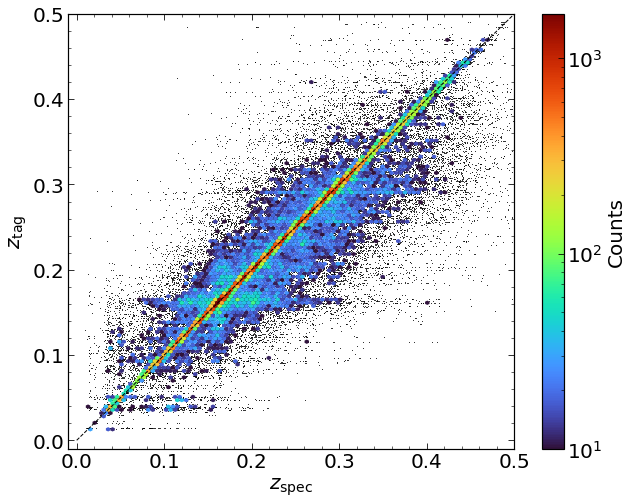

In [215]:
# Plotting the spec-z versus the new tagged-z
plt.scatter(sample['Z'],
            sample['Z_tag'],
            s=1,c='k',linewidth=0)
im=plt.hexbin(sample['Z'],sample['Z_tag'],gridsize=(100,round(100*2/3)),
              cmap='turbo',extent=(-0.01,0.5,-0.01,0.5),mincnt=10,linewidths=0,norm=matplotlib.colors.LogNorm())

plt.plot([0,0.5],[0,0.5],c='k',linestyle='dashed',linewidth=1)
plt.xlabel(r'$z_\mathrm{spec}$',fontsize=20)
plt.ylabel(r'$z_\mathrm{tag}$',fontsize=20)
plt.xlim(-0.01,0.5)
plt.ylim(-0.01,0.5)

cbar=plt.colorbar().set_label(label='Counts')
im.figure.axes[1].tick_params(labelsize=20)

plt.savefig('plots/z_tag_z_spec.jpg',bbox_inches='tight',dpi=200)

plt.show()

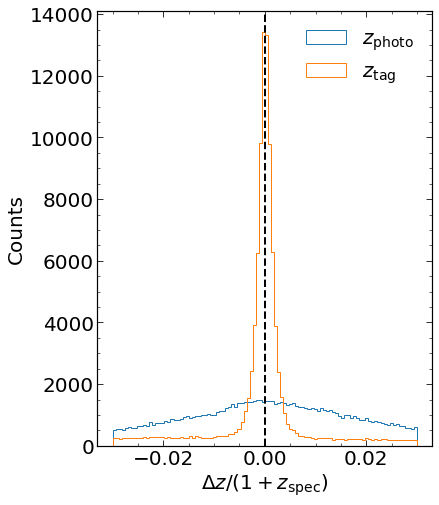

In [216]:
# Comparing the initial photometric redshifts with the new z tag
plt.figure(figsize=(6,8))
plt.hist((sample['Zpeak']-sample['Z'])/(1+sample['Z']),
         bins=np.linspace(-0.03,0.03,101),histtype='step',label='$z_\mathrm{photo}$')
plt.hist((sample['Z_tag']-sample['Z'])/(1+sample['Z']),
         bins=np.linspace(-0.03,0.03,101),histtype='step',label='$z_\mathrm{tag}$')
plt.axvline(0,c='k',linestyle='dashed',linewidth=2)
plt.xlabel('$\Delta z / (1+z_\mathrm{spec})$')
plt.ylabel('Counts')
plt.legend(frameon=False)

plt.savefig('plots/z_tag_z_photo.jpg',bbox_inches='tight',dpi=200)

plt.show()

In [217]:
# Median absolute deviation of z-tag from z-spec
np.median(abs(sample['Z_tag']-sample['Z'])/(1+sample['Z']))

0.0020901980956164377

In [218]:
# Median absolute deviation of z-photo from z-spec
np.median(abs(sample['Zpeak']-sample['Z'])/(1+sample['Z']))

0.015531760606257

In [219]:
# SMAD from z-tag
1.4826*np.median(abs(((sample['Z_tag']-sample['Z'])/(1+sample['Z'])) - 
                     np.median(((sample['Z_tag']-sample['Z'])/(1+sample['Z'])))))

0.003116780775201601

In [220]:
# SMAD from z-photo
1.4826*np.median(abs(((sample['Zpeak']-sample['Z'])/(1+sample['Z'])) - 
                     np.median(((sample['Zpeak']-sample['Z'])/(1+sample['Z'])))))

0.022953894953798085

### Halo property refinements

#### Mutliplicity

In [232]:
# First refinement being multiplicity
# We create N_new, which is probabilistic based on spline_prob
# N_new_sharp is the same using the processed p(z)'s
# N_new_threshold is appending galaxies if they are above the threshold probability
dfHalo['N_new'], dfHalo['N_new_sharp'], dfHalo['N_new_threshold']=dfHalo['N'], dfHalo['N'], dfHalo['N']

for i in tqdm(probdf.index):
    halo=probdf['halo'][i]
    dfHalo['N_new'].loc[halo]+=probdf['spline_prob'][i]
    dfHalo['N_new_sharp'].loc[halo]+=probdf['sharp_spline_prob'][i]
    if probdf['sharp_spline_prob'][i] >threshold:
        dfHalo['N_new_threshold'].loc[halo]+=1

  0%|          | 0/1856759 [00:00<?, ?it/s]

/tmp/ipykernel_1229/1064615974.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dfHalo['N_new'].loc[halo]+=probdf['spline_prob'][i]
/tmp/ipykernel_1229/1064615974.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dfHalo['N_new_sharp'].loc[halo]+=probdf['sharp_spline_prob'][i]
/tmp/ipykernel_1229/1064615974.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dfHalo['N_new_threshold'].loc[halo]+=1


In [233]:
# This is for plotting the shaded regions in the plot below
perc=95
n_bins=np.logspace(0.2,3,20)
n_centres=(n_bins[:-1] + n_bins[1:]) / 2
n_19_err_low=[]
n_19_err_high=[]
n_prob_err_low=[]
n_prob_err_high=[]
for i in tqdm(range(len(n_bins[:-1]))):
    n_low=n_bins[i]
    n_high=n_bins[i+1]
    sample=dfHalo[(dfHalo['N21']>n_low) & (dfHalo['N21']<n_high)]
    n_19_err_low.append(np.percentile(sample['N'],100-perc))
    n_19_err_high.append(np.percentile(sample['N'],perc))
    n_prob_err_low.append(np.percentile(sample['N_new_sharp'],100-perc))
    n_prob_err_high.append(np.percentile(sample['N_new_sharp'],perc))

  0%|          | 0/19 [00:00<?, ?it/s]

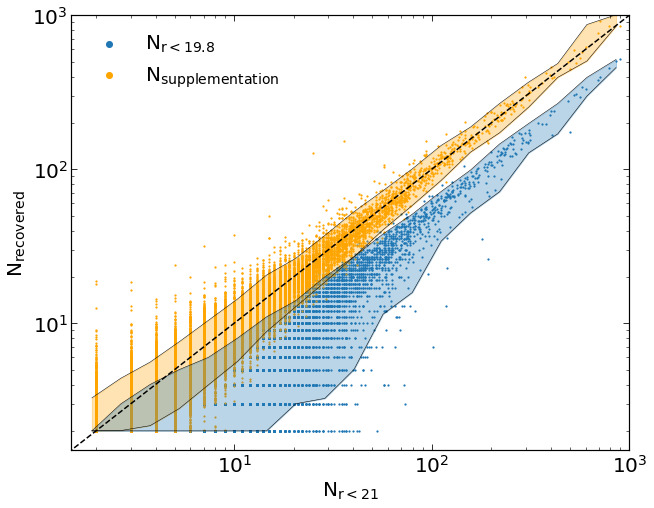

In [235]:
# Plotting the multiplicity of haloes

plt.scatter(dfHalo['N21'],dfHalo['N'],linewidth=0,s=5,label=r'$\mathrm{N_{r<19.8}}$',c='C0')
plt.scatter(dfHalo['N21'],dfHalo['N_new_sharp'],linewidth=0,s=5,label=r'$\mathrm{N_{supplementation}}$',c='orange')

plt.fill_between(n_centres, n_prob_err_low, n_prob_err_high,alpha=0.3,color='orange')
plt.fill_between(n_centres, n_19_err_low, n_19_err_high,alpha=0.3,color='C0')
plt.plot(n_centres,n_prob_err_high,c='k',linewidth=0.5)
plt.plot(n_centres,n_prob_err_low,c='k',linewidth=0.5)
plt.plot(n_centres,n_19_err_high,c='k',linewidth=0.5)
plt.plot(n_centres,n_19_err_low,c='k',linewidth=0.5)


plt.plot([1,1000],[1,1000],c='k',linestyle='dashed')
plt.xlim(1.5,1000)
plt.ylim(1.5,1000)
plt.xscale('log')
plt.yscale('log')
plt.xlabel(r'$\mathrm{N_{r<21}}$')
plt.ylabel(r'$\mathrm{N_{recovered}}$')
lgnd=plt.legend(frameon=False)
lgnd.legendHandles[0]._sizes = [50]
lgnd.legendHandles[1]._sizes = [50]
plt.savefig('plots/halo_n.jpg',bbox_inches='tight',dpi=200)
plt.show()

In [236]:
sample=dfHalo[dfHalo['N']>4]

In [237]:
# Ratio of r<19.8 to r<21 multiplicity
np.mean(sample['N']/sample['N21'])

0.5616507726370851

In [238]:
# Mean of new probabilistic N / real N
np.mean(sample['N_new_sharp']/sample['N21'])

0.9841276343721486

In [239]:
# Mean of threshold N / real N
np.mean(sample['N_new_threshold']/sample['N21'])

1.0136909899454705

In [240]:
# Median deviation frmo real N
np.median(abs(sample['N_new_sharp']-sample['N21'])/sample['N21'])

0.12925530523065376

In [241]:
# Finding the number of true assocations for each halo
true_frac=[]
thresh_frac=[]
for halo in tqdm(dfHalo.index):
    if sum(probdf[probdf['halo']==halo]['sharp_spline_prob'])>0:
        true_frac.append(sum(probdf[(probdf['halo']==halo) & (probdf['match']==True)]['sharp_spline_prob'])/(
            sum(probdf[(probdf['halo']==halo) & (probdf['match']==True)]['sharp_spline_prob']) + 
            sum(probdf[(probdf['halo']==halo) & (probdf['match']==False)]['sharp_spline_prob'])))
    else:
        true_frac.append(np.NAN)
        
    if dfHalo['N_new_threshold'][halo]>dfHalo['N'][halo]:
        thresh_frac.append(len(probdf[(probdf['halo']==halo) & (probdf['sharp_spline_prob']>threshold) & (probdf['match']==True)])/(
            len(probdf[(probdf['halo']==halo) & (probdf['sharp_spline_prob']>threshold) & (probdf['match']==True)]) +
            len(probdf[(probdf['halo']==halo) & (probdf['sharp_spline_prob']>threshold) & (probdf['match']==False)])))
    else:
        thresh_frac.append(np.NAN)

  0%|          | 0/37279 [00:00<?, ?it/s]

In [242]:
dfHalo['true_frac']=true_frac
dfHalo['threshold_frac']=thresh_frac

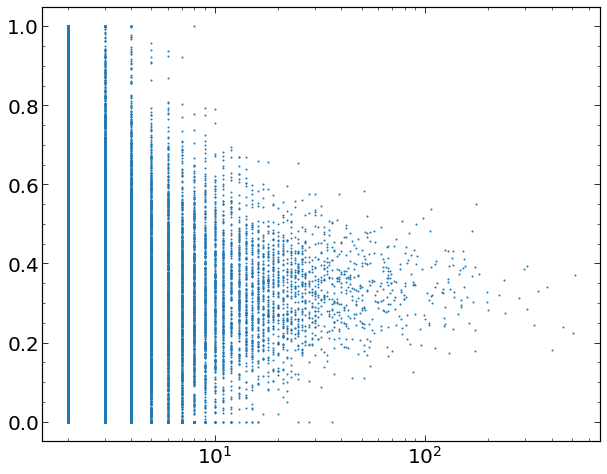

In [244]:
# Plotting true_frac (fraction of true assocations for each halo) as function of N
plt.scatter(dfHalo['N'],dfHalo['true_frac'],s=1)
plt.xscale('log')
plt.show()

#### Dynamical mass estimation

In [249]:
# Calculating the velocity dispersion of each group using the gapper method of r<19.8 members
from astropy.constants import c
C=c.value

df['v'] = df['Z'] * C/1000

# Making a dictionary of member velocities
groupdictvel={}
for i in tqdm(dfHalo.index):
    groupdictvel[i] = []
    for j in list(df19[df19['HaloID']==i].index):
        groupdictvel[i].append(df['v'][j])      
        
for i in groupdictvel:
    groupdictvel[i] = sorted(groupdictvel[i])

# Gapper method of velocity dispersions, assuming a 30kms-1 velocity error on each galaxy
s = []
for i in tqdm(dfHalo.index):
    N = len(groupdictvel[i])
    fact = np.sqrt(np.pi) / (N * (N - 1))
    wgsum=0
    for j in range(1,N):
        w = (j * (N-j))
        g = (groupdictvel[i][j] - groupdictvel[i][j-1])/(1+dfHalo['Z'][i])
        wgsum += w * g
    sgap =  fact * wgsum
    s.append(np.sqrt((N/(N-1)) * sgap**2 - (np.sqrt(N*(30**2))/np.sqrt(N))**2))
    
dfHalo['VelDisp'] = np.array(s)

  0%|          | 0/37279 [00:00<?, ?it/s]

  0%|          | 0/37279 [00:00<?, ?it/s]

/tmp/ipykernel_1229/2656648433.py:26: RuntimeWarning: invalid value encountered in sqrt
  s.append(np.sqrt((N/(N-1)) * sgap**2 - (np.sqrt(N*(30**2))/np.sqrt(N))**2))


In [252]:
# Defining the centre of each halo as the member of greatest brightness
RecCentres=[]
for group in tqdm(dfHalo.index):
    mags={}
    for galaxy in list(df19[df19['HaloID']==group].index):
        mags[galaxy] = (df['abs_mag_r01'][galaxy])
    RecCentres.append(list(mags.keys())[list(mags.values()).index(min(mags.values()))])
    
dfHalo['Centre'] = RecCentres

  0%|          | 0/37279 [00:00<?, ?it/s]

In [253]:
df['RARad']=df['RA']*(np.pi/180)
df['DecRad']=df['Dec']*(np.pi/180)

In [254]:
df['CoDistance']=cosmo.comoving_distance(np.array(df['Z'])).value *1e6 * h

In [255]:
# Radius calcuation for each halo using halo members
def radiuscalc(percentile):
    Radius=[]
    for group in tqdm(dfHalo.index):
        centre = dfHalo['Centre'][group]
        distances = []
        for galaxy in list(df19[df19['HaloID']==group].index):
            distances.append(df['CoDistance'][centre]*(angsep(df.loc[centre]['RARad'],df.loc[centre]['DecRad'],
                                                              df.loc[galaxy]['RARad'],df.loc[galaxy]['DecRad'])))
        Radius.append(np.percentile(distances,percentile,interpolation='linear'))
    return Radius

dfHalo['Radius50'] = radiuscalc(50)

  0%|          | 0/37279 [00:00<?, ?it/s]

In [257]:
# Dynamical mass relation
def DynMass(A,VelDisp,Radius):
    return (A/(G)) * (VelDisp)**2 * ((Radius/1e6)/h**-1)

In [258]:
from astropy.constants import G
G = G.to(u.M_sun**-1 * u.km**2 * u.s**-2 * u.Mpc).value

In [259]:
dfHalo['DynMassRaw'] = DynMass(1,dfHalo['VelDisp'],dfHalo['Radius50'])

#### Dynamical mass A parameter inference

In [260]:
# Importing emcee, the package we used for the parameter inference
import emcee
import corner

In [262]:
sample=dfHalo[dfHalo['N']>4]

In [263]:
# model of A parameter, depending on Ac, An and Az
def model(theta,mass=sample['DynMassRaw'], n=sample['N'], z=sample['Z']):
    A_c, A_n, A_z = theta
    model = mass * (A_c + (A_n/np.sqrt(n)) + (A_z/np.sqrt(z)))
    return model

In [265]:
# log likelihood function
def lnprob(theta, x, y, yerr):
    lp = lnprior(theta)
    if not np.isfinite(lp):
        return -np.inf
    return lp + lnlike(theta, x, y, yerr)

def lnlike(theta, x, y, yerr):
    return -0.5 * np.sum(((np.log10(y) - np.log10(model(theta, x)))) ** 2)

# priors

def lnprior(theta):
    A_c, A_n, A_z = theta
    if -5 < A_c < 5 and 0 < A_n < 25 and -2 < A_z < 3:
        return 0.0
    return -np.inf

In [267]:
# Implementing a 1% error on Mass
M_err = np.log10(0.01*np.mean(sample['Mass']))
data = (sample['DynMassRaw'], sample['Mass'] ,M_err)
nwalkers = 240
niter = 1000
initial = np.array([0,20,2])
ndim = len(initial)
p0 = [np.array(initial) + 1e-7 * np.random.randn(ndim) for i in range(nwalkers)]

In [268]:
def main(p0,nwalkers,niter,ndim,lnprob,data):
    sampler = emcee.EnsembleSampler(nwalkers, ndim, lnprob, args=data)

    print("Running burn-in...")
    p0, _, _ = sampler.run_mcmc(p0, 100)
    sampler.reset()

    print("Running production...")
    pos, prob, state = sampler.run_mcmc(p0, niter)

    return sampler, pos, prob, state

In [269]:
%%time
# Running emcee
sampler, pos, prob, state = main(p0,nwalkers,niter,ndim,lnprob,data)

Running burn-in...


/its/home/tc339/.conda/envs/env/lib/python3.8/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


Running production...
CPU times: user 7min 20s, sys: 1.71 s, total: 7min 22s
Wall time: 7min 16s


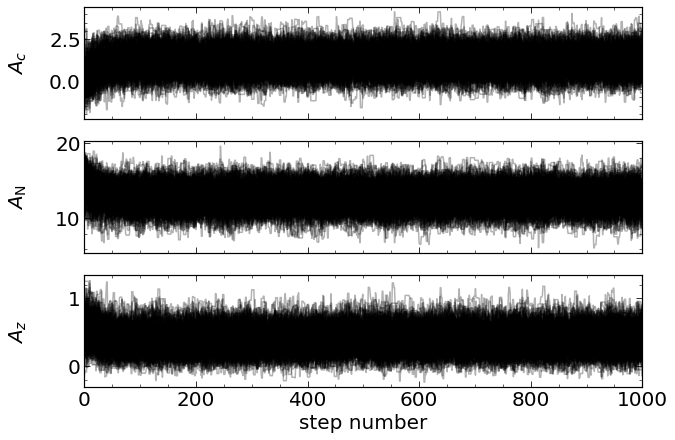

In [270]:
# Plot the samples
fig, axes = plt.subplots(3, figsize=(10, 7), sharex=True)
labels = ['$A_c$', '$A_\mathrm{N}$', '$A_z$']
for i in range(ndim):
    ax = axes[i]
    ax.plot(sampler.get_chain()[:, :, i], "k", alpha=0.3)
    ax.set_xlim(0, len(sampler.get_chain()))
    ax.set_ylabel(labels[i])
    ax.yaxis.set_label_coords(-0.1, 0.5)

axes[-1].set_xlabel("step number")
plt.show()

In [271]:
samples = sampler.flatchain
theta=samples[np.argmax(sampler.flatlnprobability)]

/its/home/tc339/.conda/envs/env/lib/python3.8/site-packages/corner/core.py:635: UserWarning: marker is redundantly defined by the 'marker' keyword argument and the fmt string "o" (-> marker='o'). The keyword argument will take precedence.
  ax.plot(x, y, "o", zorder=-1, rasterized=True, **data_kwargs)
/its/home/tc339/.conda/envs/env/lib/python3.8/site-packages/corner/core.py:635: UserWarning: marker is redundantly defined by the 'marker' keyword argument and the fmt string "o" (-> marker='o'). The keyword argument will take precedence.
  ax.plot(x, y, "o", zorder=-1, rasterized=True, **data_kwargs)
/its/home/tc339/.conda/envs/env/lib/python3.8/site-packages/corner/core.py:635: UserWarning: marker is redundantly defined by the 'marker' keyword argument and the fmt string "o" (-> marker='o'). The keyword argument will take precedence.
  ax.plot(x, y, "o", zorder=-1, rasterized=True, **data_kwargs)


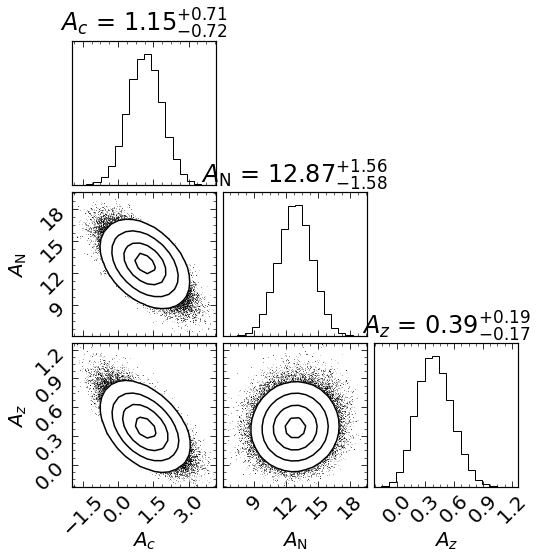

In [274]:
# Corner plot of parameters

data_kwargs={}
data_kwargs['marker']='.'
data_kwargs['alpha']=1
data_kwargs['markeredgewidth']=0
data_kwargs['ms']=1

contourf_kwargs={}

contour_kwargs={}
contour_kwargs['linewidths']=1


labels = ['$A_c$', '$A_\mathrm{N}$', '$A_z$']
fig = corner.corner(samples,show_titles=True,labels=labels,plot_datapoints=True,
                    smooth=2,hist_bin_factor=1,plot_density=False,
                    data_kwargs=data_kwargs)

plt.savefig('plots/mass_corner_plot.jpg', bbox_inches='tight', dpi=200)

In [275]:
theta[0]=np.median(samples[:,0])
theta[1]=np.median(samples[:,1])
theta[2]=np.median(samples[:,2])

In [276]:
# Giving each halo an A parameter, and recalculating dynamical mass
def A(N,Z):
    return theta[0]+(theta[1]/np.sqrt(N))+(theta[2]/np.sqrt(Z))

dfHalo['A'] = A(dfHalo['N'],dfHalo['Z'])

dfHalo['DynMassA'] = DynMass(dfHalo['A'],dfHalo['VelDisp'],dfHalo['Radius50'])

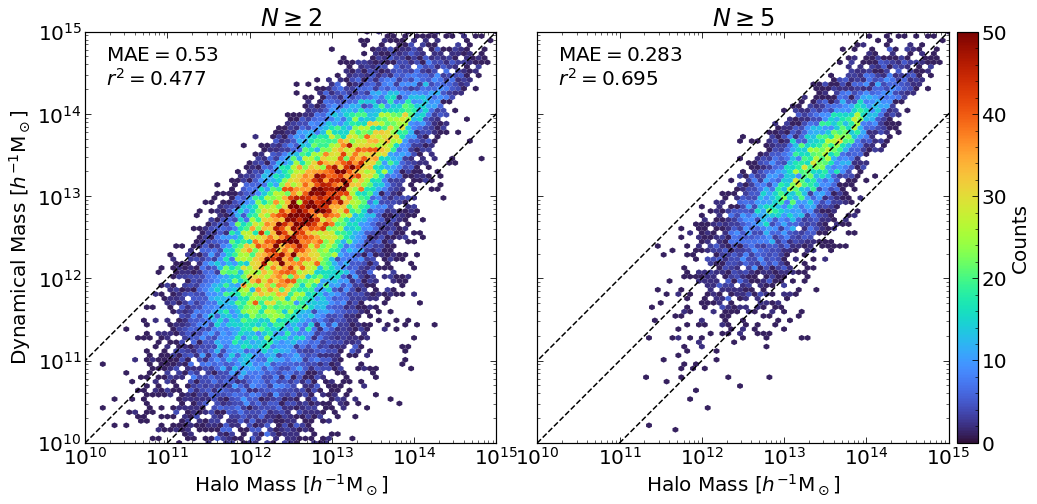

In [281]:
# Plotting dynamical mass vs true halo mass

fig, axs = plt.subplots(1,2, facecolor='w', edgecolor='k',gridspec_kw={'width_ratios': [1, 1]},figsize=(16,8))
fig.subplots_adjust(hspace = 0, wspace=0.1)
axs=axs.ravel()

sample=dfHalo[(dfHalo['DynMassA']>0) & (dfHalo['N']>1)]
MAE=sum(abs(np.log10(sample['DynMassA'])-np.log10(sample['Mass']))/len(sample))
r2=1-(sum((np.log10(sample['DynMassA'])-np.log10(sample['Mass']))**2)/
      sum((np.log10(sample['DynMassA'])-np.mean(np.log10(sample['Mass'])))**2))

axs[0].hexbin(sample['Mass'],
              sample['DynMassA'],
              gridsize=(70,round(70*2/3)),cmap='turbo',extent=(10,15,10,15),mincnt=1,
              linewidths=0,vmin=0,vmax=50,xscale='log',yscale='log')
axs[0].plot([1e8,1e16],[1e8,1e16],c='k',linestyle='dashed')
axs[0].plot([1e8,1e15],[1e9,1e16],c='k',linestyle='dashed')
axs[0].plot([1e9,1e16],[1e8,1e15],c='k',linestyle='dashed')
axs[0].set_xlim(1e10,1e15)
axs[0].set_ylim(1e10,1e15)
axs[0].set_xlabel('Halo Mass [$h^{-1}\mathrm{M_\odot}$]')
axs[0].set_ylabel('Dynamical Mass [$h^{-1}\mathrm{M_\odot}$]')
axs[0].set_title('$N \geq 2$')
axs[0].set_aspect('equal', adjustable='box')
axs[0].text(0.05,0.93, '$\mathrm{MAE} = $'+str(round(MAE,3)), transform=axs[0].transAxes)
axs[0].text(0.05,0.87, '$r^2 = $'+str(round(r2,3)), transform=axs[0].transAxes)




sample=dfHalo[(dfHalo['DynMassA']>0) & (dfHalo['N']>4)]
MAE=sum(abs(np.log10(sample['DynMassA'])-np.log10(sample['Mass']))/len(sample))
r2=1-(sum((np.log10(sample['DynMassA'])-np.log10(sample['Mass']))**2)/
      sum((np.log10(sample['DynMassA'])-np.mean(np.log10(sample['Mass'])))**2))

axs[1].hexbin(sample['Mass'],
              sample['DynMassA'],
              gridsize=(70,round(70*2/3)),cmap='turbo',extent=(10,15,10,15),mincnt=1,
              linewidths=0,vmin=0,vmax=50,xscale='log',yscale='log')
axs[1].plot([1e8,1e16],[1e8,1e16],c='k',linestyle='dashed')
axs[1].plot([1e8,1e15],[1e9,1e16],c='k',linestyle='dashed')
axs[1].plot([1e9,1e16],[1e8,1e15],c='k',linestyle='dashed')
axs[1].set_xlim(1e10,1e15)
axs[1].set_ylim(1e10,1e15)
axs[1].set_xlabel('Halo Mass [$h^{-1}\mathrm{M_\odot}$]')
axs[1].yaxis.set_ticklabels([])
axs[1].set_title('$N \geq 5$')
axs[1].set_aspect('equal', adjustable='box')
axs[1].text(0.05,0.93, '$\mathrm{MAE} = $'+str(round(MAE,3)), transform=axs[1].transAxes)
axs[1].text(0.05,0.87, '$r^2 = $'+str(round(r2,3)), transform=axs[1].transAxes)



im = plt.gca().get_children()[0]
fig.colorbar(im, ax=axs,pad=0.01,fraction=0.023,label='Counts')

plt.savefig('plots/dyn_mass_halo_mass.jpg', bbox_inches='tight', dpi=200)

plt.show()

#### Luminosity mass

In [282]:
dfHalo['LumDistance'] = cosmo.luminosity_distance(np.array(dfHalo['Z'])).value * h * 1e6

In [286]:
# Function for converting magnitude to luminosity
def lumconv(mag):
    return  10**(0.4 *(4.67- mag))

# Function for converting luminosity to halo mass (from Rana et al.)
def massconv(lum):
    return 1e14 * h**-1 * (0.81) * (lum/(10**11.5 * h**-2))**(1.01)

In [287]:
df['lum']=lumconv(df['abs_mag_r01'])
df19['lum']=lumconv(df19['abs_mag_r01'])

In [288]:
# Summing the luminosity of halo members

lum19_raw_arr=[]
lum21_raw_arr=[]
for halo in tqdm(dfHalo.index):
    # For r<21 members
    lum21_raw_arr.append(sum(df[df['HaloID']==halo]['lum']))
    
    # For r<19.8 members
    lum19_raw_arr.append(sum(df19[df19['HaloID']==halo]['lum']))

  0%|          | 0/37279 [00:00<?, ?it/s]

In [289]:
dfHalo['lum19raw'] = lum19_raw_arr
dfHalo['lum21raw'] = lum21_raw_arr

In [291]:
# This cell calculates the luminosity factor for each halo
# This is based on extrapolating the luminosity function beyond the magnitude limit of the survey

z_arr=np.linspace(0,0.6,1000)
distance_arr=cosmo.luminosity_distance(np.linspace(0,0.6,1000)).value*h*1e6

def mlim19(distance):
    return 19.8 - 5*np.log10(distance) + 5 

def mlim21(distance):
    return 21 - 5*np.log10(distance) + 5 

# Schechter luminosity function
def sch(M,M_star,alpha,phi):
    return 0.4 * np.log(10) * phi * (10**(0.4*(M_star - M)*(alpha+1))) * np.exp(-10**(0.4*(M_star - M)))

# These are the parameters I've derived from the Euclid FS2 luminosity function
alpha=-1.3821217577078246
M_star=-21.01915172512823
phi_star=0.0032322947599253467


from scipy import integrate

def lumest(M,M_star,alpha,phi):
    return 10**(-0.4*M) * sch(M, M_star, alpha, phi)

num = integrate.quad(lumest,-30,-14,args=(M_star,alpha,phi_star))[0]

Lumfacarr19=[]
Lumfacarr21=[]

for i in tqdm(dfHalo.index):
    Lumfacarr19.append(num / integrate.quad(lumest,-30,mlim19(dfHalo['LumDistance'][i]),
                                            args=(M_star,alpha,phi_star))[0])
    
    Lumfacarr21.append(num / integrate.quad(lumest,-30,mlim21(dfHalo['LumDistance'][i]),
                                            args=(M_star,alpha,phi_star))[0])

# Luminosity factor for r<19.8
dfHalo['Lumfac19'] = Lumfacarr19

# Luminosity factor for r<21
dfHalo['Lumfac21'] = Lumfacarr21

  0%|          | 0/37279 [00:00<?, ?it/s]

In [292]:
# r<19 luminosity as the multiplication of the lum factor and the raw lum
dfHalo['lum19']=dfHalo['Lumfac19'] * dfHalo['lum19raw']

In [293]:
# Finding the probabilistic luminosity of each halo by summing fractional luminosity of members
lum_sup_arr=[]
for halo in tqdm(dfHalo.index):
    lum=dfHalo.loc[halo]['lum19raw']
    subset=probdf[probdf['halo']==halo]
    lum_sup_arr.append(lum + sum(subset['sharp_spline_prob'].values * 
             df.loc[subset['gal'].values]['lum'].values))

  0%|          | 0/37279 [00:00<?, ?it/s]

In [294]:
dfHalo['lum_sup']=lum_sup_arr

In [295]:
# Converting the luminosities into masses
dfHalo['mass19']=massconv(dfHalo['lum19'])
dfHalo['mass_sup']=massconv(dfHalo['lum_sup']*dfHalo['Lumfac21'])

In [296]:
font = {'size'   : 20}
plt.rc('font', **font)

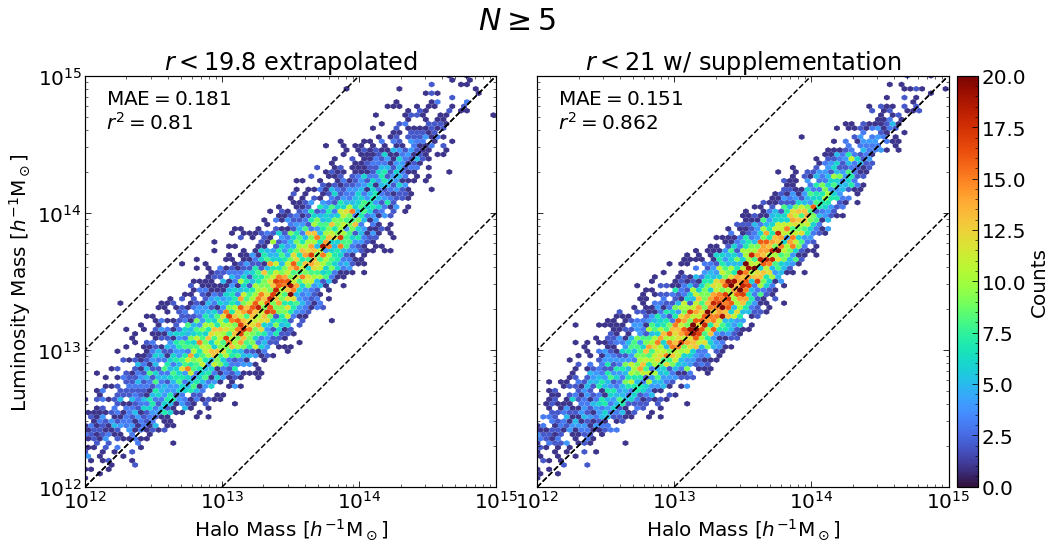

In [299]:
# Plotting the extrapolated luminosity mass and the supplemented luminosity mass vs the true halo mass

sample=dfHalo[dfHalo['N']>4]
fig, axs = plt.subplots(1,2, facecolor='w', edgecolor='k',gridspec_kw={'width_ratios': [1, 1]},figsize=(16,8))
fig.subplots_adjust(hspace = 0, wspace=0.1)
axs=axs.ravel()

MAE=sum(abs(np.log10(sample['mass19'])-np.log10(sample['Mass']))/len(sample))
r2=1-(sum((np.log10(sample['mass19'])-np.log10(sample['Mass']))**2)/
      sum((np.log10(sample['mass19'])-np.mean(np.log10(sample['Mass'])))**2))
axs[0].hexbin(sample['Mass'],sample['mass19'],
              gridsize=(70,round(70*2/3)),cmap='turbo',
              extent=(12,15,12,15),mincnt=1,linewidths=0,
              vmin=0,vmax=20,xscale='log',yscale='log')
axs[0].plot([1e8,1e16],[1e8,1e16],c='k',linestyle='dashed')
axs[0].plot([1e8,1e16],[1e8,1e16],c='k',linestyle='dashed')
axs[0].plot([1e8,1e15],[1e9,1e16],c='k',linestyle='dashed')
axs[0].plot([1e9,1e16],[1e8,1e15],c='k',linestyle='dashed')
axs[0].set_xlim(1e12,1e15)
axs[0].set_ylim(1e12,1e15)
axs[0].set_xlabel('Halo Mass [$h^{-1} \mathrm{M_\odot}$]')
axs[0].set_ylabel('Luminosity Mass [$h^{-1} \mathrm{M_\odot}$]')
axs[0].set_title('$r < 19.8 \ \mathrm{extrapolated}$')
axs[0].set_aspect('equal', adjustable='box')
axs[0].text(0.05,0.93, '$\mathrm{MAE} = $'+str(round(MAE,3)), transform=axs[0].transAxes)
axs[0].text(0.05,0.87, '$r^2 = $'+str(round(r2,3)), transform=axs[0].transAxes)


MAE=sum(abs(np.log10(sample['mass_sup'])-np.log10(sample['Mass']))/len(sample))
r2=1-(sum((np.log10(sample['mass_sup'])-np.log10(sample['Mass']))**2)/
      sum((np.log10(sample['mass_sup'])-np.mean(np.log10(sample['Mass'])))**2))
axs[1].hexbin(sample['Mass'],sample['mass_sup'],
              gridsize=(70,round(70*2/3)),cmap='turbo',
              extent=(12,15,12,15),mincnt=1,linewidths=0,
              vmin=0,vmax=20,xscale='log',yscale='log')
axs[1].plot([1e8,1e16],[1e8,1e16],c='k',linestyle='dashed')
axs[1].plot([1e8,1e16],[1e8,1e16],c='k',linestyle='dashed')
axs[1].plot([1e8,1e15],[1e9,1e16],c='k',linestyle='dashed')
axs[1].plot([1e9,1e16],[1e8,1e15],c='k',linestyle='dashed')
axs[1].set_xlim(1e12,1e15)
axs[1].set_ylim(1e12,1e15)
axs[1].set_xlabel('Halo Mass [$h^{-1} \mathrm{M_\odot}$]')
axs[1].yaxis.set_ticklabels([])
axs[1].set_title('$r < 21 \ \mathrm{w/ \ supplementation}$')
axs[1].set_aspect('equal', adjustable='box')
axs[1].text(0.05,0.93, '$\mathrm{MAE} = $'+str(round(MAE,3)), transform=axs[1].transAxes)
axs[1].text(0.05,0.87, '$r^2 = $'+str(round(r2,3)), transform=axs[1].transAxes)


#cax = fig.add_axes([0.85,0.1,0.03,0.8]) 
im = plt.gca().get_children()[0]
fig.colorbar(im, ax=axs,pad=0.01,fraction=0.023,label='Counts')
fig.suptitle('$N\geq5$',fontsize=30)


plt.savefig('plots/lum_mass_halo_mass.jpg',bbox_inches='tight',dpi=200) 

plt.show()

### Extra plots

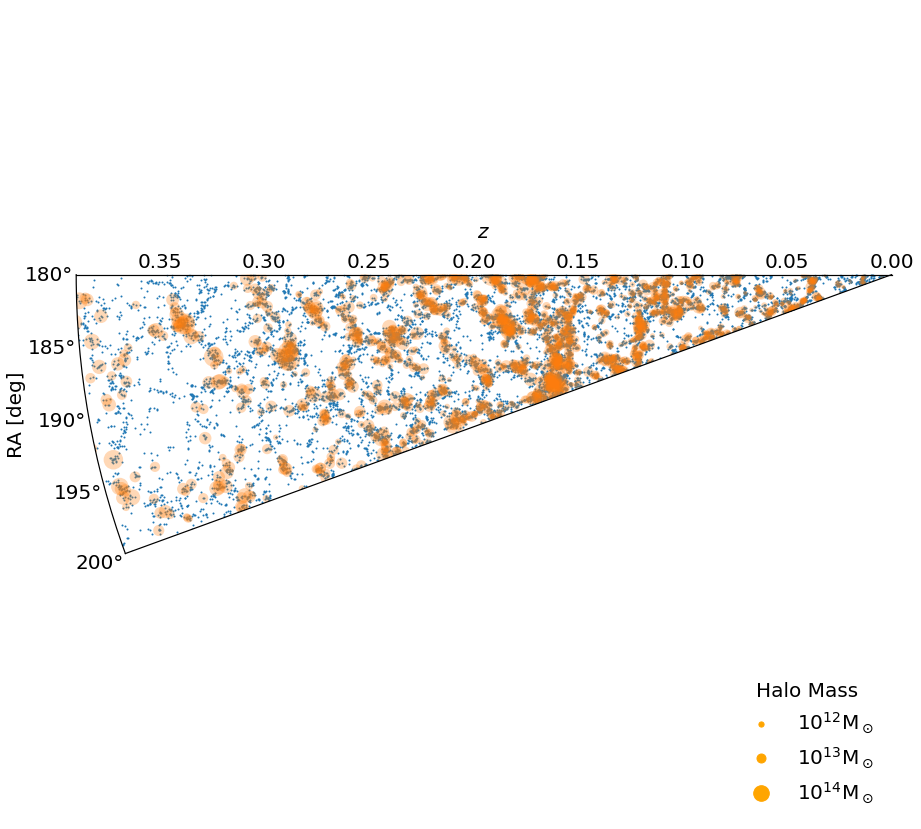

In [316]:
fig = plt.figure(figsize=(15,15))
from mpl_toolkits.axes_grid1 import make_axes_locatable

import math
ax = plt.subplot(111, polar=True)
DecDown=1
DecUp=2

dflimit=df[(df['Dec'] > DecDown) & (df['Dec'] < DecUp) & (df['Rpetro'] < 19.8)]
c=ax.scatter(dflimit['RA']*np.pi/180,
           dflimit['Z'],s=1)

dflimit=dfHalo[(dfHalo['Dec'] > DecDown) & (dfHalo['Dec'] < DecUp)]
c=ax.scatter(dflimit['RA']*np.pi/180,
           dflimit['Z'],s=3**(np.log10(dflimit['Mass'])-9),alpha=0.3,linewidth=0)

for area in [12,13,14]:
    plt.scatter([], [], s=3**(area-9),
                label='$10^{' + str(area) + '}$'+'$\mathrm{M}_\odot$',c='orange')
    
    
plt.legend(frameon=False, title='Halo Mass',loc='lower right')

ax.set_thetamin(min(df['RA']))
ax.set_thetamax(max(df['RA']))

ax.set_rmax(0.39)
ax.grid(None)

ax.set_xticks(np.array([180,185,190,195,200])*np.pi/180)
ax.tick_params(axis='x', which='major', pad=20)

ax.set_xlabel('$z$',labelpad=-600)
ax.set_ylabel('RA [deg]', labelpad=50)#,rotation=0)

plt.savefig('plots/Lightcone.jpg', bbox_inches='tight', dpi=200)


plt.show()

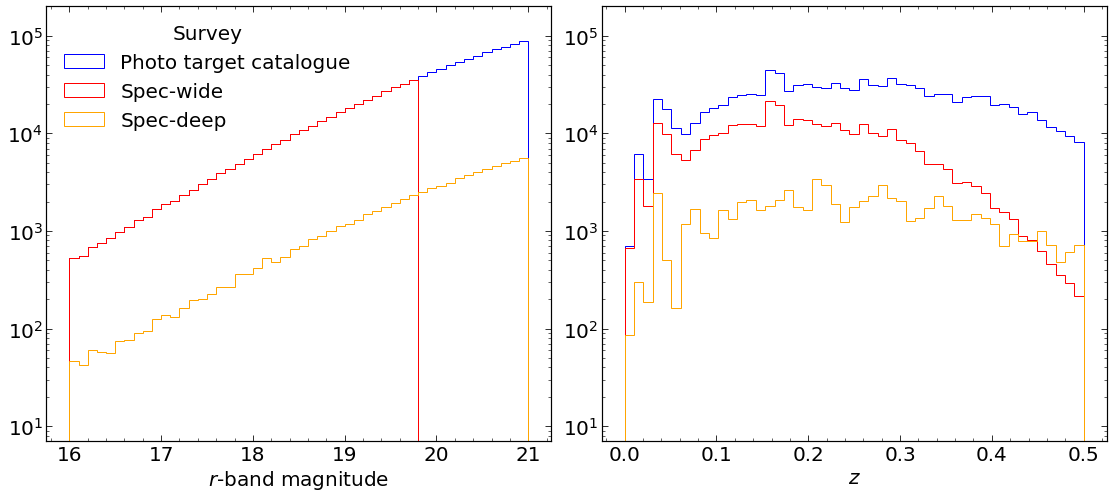

In [317]:
fig, axs = plt.subplots(1,2, facecolor='w', edgecolor='k',gridspec_kw={'width_ratios': [1, 1]},figsize=(19,8))
fig.subplots_adjust(hspace = 0, wspace=0.1)
axs=axs.ravel()

axs[1].hist(df['Z'],histtype='step',bins=np.linspace(0,0.5,50),color='blue')
axs[1].hist(df19['Z'],histtype='step',bins=np.linspace(0,0.5,50),color='red')
axs[1].hist(dftrain['Z'],histtype='step',bins=np.linspace(0,0.5,50),color='orange')
axs[1].set_yscale('log')
axs[1].set_ylim(7,2e5)
axs[1].set_xlabel('$z$')

axs[0].hist(df['Rpetro'],histtype='step',bins=np.linspace(16,21,51),label='Photo target catalogue',color='blue')
axs[0].hist(df19['Rpetro'],histtype='step',bins=np.linspace(16,21,51),label='Spec-wide',color='red')
axs[0].hist(dftrain['Rpetro'],histtype='step',bins=np.linspace(16,21,51),label='Spec-deep',color='orange')
axs[0].set_yscale('log')
axs[0].set_ylim(7,2e5)
axs[0].set_xlabel('$r$'+'-band magnitude')
axs[0].legend(title='Survey',frameon=False,loc='upper left')

plt.savefig('plots/survey_comparison.jpg', bbox_inches='tight', dpi=200)

plt.show()